# Card Support — Cards & Customers Exploratory Data Analysis

**Goal.** Build a complete understanding of the card-related data in the LATAM Bank dataset
(card types, statuses, segments, limits, utilization, days past due, payments, authorizations,
fraud, and the service demand they generate) to ground the **Card Support** workflow.

**Scope.** `customers`, `products` (credit & debit cards), `transactions` on cards,
`complaints`, `call_center_interactions`, `call_transcripts`, `digital_events`, `daily_exchange_rates`.

**Conventions**
- Source: the canonical `data/` delivery (S3 prefix `data/`, uploaded 2026-08-31). No backup copies are used.
- **As-of date = 2026-06-17** (last day of the fact partitions). All ages, expirations and recencies are computed against it.
- Amounts are compared in **USD** using `daily_exchange_rates` (as-of rate for snapshot balances; transaction-date rate for transactions).
- Privacy: the repo is public, so outputs are **aggregates only**. Card numbers are masked (`**** 1234`); names, document numbers, emails, phones and addresses are never printed.
- Every notable observation is registered with `note(...)` and summarised in the **Findings register** at the end.

| # | Section |
|---|---|
| 0 | Setup & data loading |
| 1 | Data quality for card-relevant tables |
| 2 | Card portfolio |
| 3 | Cardholder & customer profile |
| 4 | Credit-card terms & risk (limits, utilization, interest, days past due) |
| 5 | Payments & payment timing |
| 6 | Card transactions & authorizations (declines, response codes, fraud) |
| 7 | Card-support demand signals (complaints, interactions, digital) |
| 8 | Implications for the Card Support workflow |
| 9 | Findings register |

## 0. Setup & data loading

DuckDB queries the CSVs directly. The partitioned fact tables are converted once to Parquet under
`data/_parquet/` (git-ignored) so re-runs take seconds. The first run takes a few minutes, mostly for `digital_events` (3.6 GB).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA = ROOT / "data"
CACHE = DATA / "_parquet"
CACHE.mkdir(exist_ok=True)
AS_OF = "2026-06-17"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

con = duckdb.connect()
con.execute("SET preserve_insertion_order = false")


def sql(query: str) -> pd.DataFrame:
    return con.sql(query).df()


FINDINGS: list[dict] = []


def note(area: str, finding: str, impact: str) -> None:
    """Register a finding for the summary table at the end of the notebook."""
    FINDINGS.append({"area": area, "finding": finding, "impact_on_card_support": impact})

### Chart style
A single visual system across the notebook: validated categorical palette in fixed slot order
(Credit = blue, Debit = orange everywhere), a one-hue blue ramp for magnitude, recessive hairline grids.

In [2]:
C = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CAT = list(C.values())
CARD_COLORS = {"Credit": C["blue"], "Debit": C["orange"]}
SEQ_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]
ORDINAL = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", SEQ_RAMP)
INK, INK2, MUTED, GRID, BASELINE, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10, "font.family": "sans-serif",
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": BASELINE,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.axisbelow": True, "lines.linewidth": 2, "lines.solid_capstyle": "round",
    "legend.frameon": False, "legend.fontsize": 9,
})


def _fmt(v, kind):
    if kind == "pct":
        return f"{v:.1%}"
    if kind == "usd":
        return f"${v:,.0f}"
    if kind == "float":
        return f"{v:,.1f}"
    return f"{v:,.0f}"


def hbar(ax, s: pd.Series, color=C["blue"], kind="int", title=None, xlabel=None):
    """Horizontal bars (first item on top) with the value at the tip."""
    s = s.iloc[::-1]
    bars = ax.barh(s.index.astype(str), s.values, color=color, height=0.6)
    for b, v in zip(bars, s.values):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, "  " + _fmt(v, kind), va="center", color=INK2, fontsize=8.5)
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.18)
    if kind == "pct":
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    else:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def grouped_hbar(ax, df: pd.DataFrame, colors: dict, kind="int", title=None, xlabel=None, labels=True):
    """Horizontal grouped bars: index = categories (top to bottom), columns = series."""
    df = df.iloc[::-1]
    n = len(df.columns)
    h = 0.8 / n
    y = np.arange(len(df))
    for i, col in enumerate(df.columns):
        pos = y + (i - (n - 1) / 2) * h * -1
        bars = ax.barh(pos, df[col].values, height=h * 0.92, color=colors[col], label=col)
        if labels:
            for b, v in zip(bars, df[col].values):
                if pd.notna(v):
                    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, " " + _fmt(v, kind), va="center", color=INK2, fontsize=8)
    ax.set_yticks(y, df.index.astype(str))
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.2)
    if kind == "pct":
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    else:
        ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax


def heat(ax, df: pd.DataFrame, fmt=".1%", title=None, cbar=False):
    sns.heatmap(df, ax=ax, cmap=SEQ, annot=True, fmt=fmt, linewidths=2, linecolor=SURFACE,
                cbar=cbar, annot_kws={"fontsize": 8.5})
    ax.grid(False)
    ax.tick_params(axis="both", length=0)
    ax.set_xlabel(ax.get_xlabel(), color=INK2)
    ax.set_ylabel(ax.get_ylabel(), color=INK2)
    if title:
        ax.set_title(title)
    return ax


def pct_table(df: pd.DataFrame, cols=None):
    """Style helper: format ratio columns as percentages in displayed tables."""
    cols = cols or [c for c in df.columns if c.endswith(("_rate", "_share", "_pct"))]
    return df.style.format({c: "{:.1%}" for c in cols}, na_rep="—").format(
        {c: "{:,.0f}" for c in df.select_dtypes("number").columns if c not in cols}, na_rep="—")

### Load tables

In [3]:
def cache_fact(name: str, select: str = "*", all_varchar: bool = False) -> Path:
    out = CACHE / f"{name}.parquet"
    if not out.exists():
        opts = "all_varchar=true" if all_varchar else "sample_size=-1"
        src = f"read_csv('{DATA}/{name}/**/*.csv', header=true, union_by_name=true, {opts})"
        con.execute(f"COPY (SELECT {select} FROM {src}) TO '{out}' (FORMAT parquet)")
    return out


paths = {
    "transactions": cache_fact("transactions"),
    "call_center_interactions": cache_fact("call_center_interactions"),
    "complaints": cache_fact("complaints"),
    "call_transcripts": cache_fact(
        "call_transcripts",
        "transcript_id, interaction_id, customer_id, customer_text, detected_intents, main_topics, process_date"),
    "digital_events": cache_fact(
        "digital_events",
        "event_id, try_cast(event_date AS TIMESTAMP) AS event_date, customer_id, session_id, event_type, "
        "event_category, channel, page_url, product_id",
        all_varchar=True),
}

con.execute(f"CREATE OR REPLACE TABLE customers_raw AS SELECT * FROM read_csv_auto('{DATA}/customers.csv')")
con.execute(f"CREATE OR REPLACE TABLE products AS SELECT * FROM read_csv_auto('{DATA}/products.csv', types={{'product_number': 'VARCHAR'}})")
con.execute(f"CREATE OR REPLACE TABLE fx AS SELECT * FROM read_csv_auto('{DATA}/daily_exchange_rates.csv')")
con.execute(f"CREATE OR REPLACE VIEW transactions AS SELECT * FROM '{paths['transactions']}'")
con.execute(f"CREATE OR REPLACE TABLE interactions AS SELECT * FROM '{paths['call_center_interactions']}'")
con.execute(f"CREATE OR REPLACE TABLE complaints AS SELECT * FROM '{paths['complaints']}'")
con.execute(f"CREATE OR REPLACE VIEW transcripts AS SELECT * FROM '{paths['call_transcripts']}'")
con.execute(f"CREATE OR REPLACE VIEW digital_events AS SELECT * FROM '{paths['digital_events']}'")
print("loaded")

loaded


### Derived views
- `fx_asof`: local currency → USD at the as-of date.
- `customers`: adds local currency, income in USD, age, credit-score band.
- `cards`: credit and debit cards only, with card type, USD amounts, utilization, days-past-due bucket, expiration status and the masked number.
- `card_tx`: transactions on cards, enriched with card attributes and a filled `amount_usd`.

In [4]:
con.execute(f"""
CREATE OR REPLACE TABLE fx_asof AS
SELECT source_currency AS currency, exchange_rate AS to_usd
FROM fx WHERE date = DATE '{AS_OF}' AND target_currency = 'USD'
UNION ALL SELECT 'USD', 1.0
""")

con.execute(f"""
CREATE OR REPLACE TABLE customers AS
SELECT c.*,
       CASE c.country WHEN 'México' THEN 'MXN' WHEN 'Colombia' THEN 'COP' WHEN 'Argentina' THEN 'ARS' END AS local_currency,
       c.estimated_monthly_income * f.to_usd AS income_usd,
       date_diff('year', c.date_of_birth, DATE '{AS_OF}') AS age,
       CASE WHEN c.credit_score IS NULL THEN 'Unknown'
            WHEN c.credit_score < 580 THEN '1 Poor (<580)'
            WHEN c.credit_score < 670 THEN '2 Fair (580-669)'
            WHEN c.credit_score < 740 THEN '3 Good (670-739)'
            WHEN c.credit_score < 800 THEN '4 Very good (740-799)'
            ELSE '5 Exceptional (800+)' END AS score_band
FROM customers_raw c
LEFT JOIN fx_asof f ON f.currency = CASE c.country WHEN 'México' THEN 'MXN' WHEN 'Colombia' THEN 'COP' WHEN 'Argentina' THEN 'ARS' END
""")

con.execute(f"""
CREATE OR REPLACE TABLE cards AS
SELECT p.* EXCLUDE (product_number),
       '**** ' || right(p.product_number, 4) AS card_masked,
       CASE p.product_type WHEN 'Tarjeta Crédito' THEN 'Credit' ELSE 'Debit' END AS card_type,
       p.current_balance * f.to_usd AS balance_usd,
       p.credit_limit * f.to_usd AS limit_usd,
       p.current_balance / nullif(p.credit_limit, 0) AS utilization,
       date_diff('month', p.opening_date, p.expiration_date) AS term_months,
       year(p.opening_date) AS open_year,
       CASE WHEN p.product_type <> 'Tarjeta Crédito' THEN NULL
            WHEN p.days_past_due IS NULL THEN 'Unknown'
            WHEN p.days_past_due = 0 THEN '0 (current)'
            ELSE CAST(CAST(p.days_past_due AS INT) AS VARCHAR) END AS dpd_bucket,
       CASE WHEN p.expiration_date IS NULL THEN 'Unknown'
            WHEN p.expiration_date < DATE '{AS_OF}' THEN 'Expired'
            WHEN p.expiration_date <= DATE '{AS_OF}' + INTERVAL 30 DAY THEN '≤30 days'
            WHEN p.expiration_date <= DATE '{AS_OF}' + INTERVAL 90 DAY THEN '31-90 days'
            WHEN p.expiration_date <= DATE '{AS_OF}' + INTERVAL 180 DAY THEN '91-180 days'
            ELSE '>180 days' END AS expiry_status,
       c.segment, c.country, c.customer_status, c.score_band, c.credit_score, c.income_usd, c.age
FROM products p
JOIN fx_asof f USING (currency)
LEFT JOIN customers c USING (customer_id)
WHERE p.product_type LIKE 'Tarjeta%'
""")

con.execute("""
CREATE OR REPLACE TABLE card_tx AS
SELECT t.*,
       coalesce(t.amount_usd, CASE WHEN t.currency = 'USD' THEN t.amount END, t.amount * fx.exchange_rate) AS amount_usd_filled,
       k.card_type, k.product_status, k.opening_date, k.expiration_date, k.segment,
       k.country AS customer_country
FROM transactions t
JOIN cards k USING (product_id)
LEFT JOIN fx ON fx.date = CAST(t.transaction_date AS DATE) AND fx.source_currency = t.currency AND fx.target_currency = 'USD'
""")
sql("SELECT (SELECT count(*) FROM customers) AS customers, (SELECT count(*) FROM cards) AS cards, (SELECT count(*) FROM card_tx) AS card_transactions")

,customers,cards,card_transactions
0,150000,140040,1547432


## 1. Data quality for card-relevant tables

The organisers announced deliberate quality problems: ~2% duplicates, ~5% nulls, late arrivals,
schema evolution and orphan foreign keys. Here we measure what this delivery actually contains before relying on it.

### 1.1 Row counts vs. the data dictionary

In [5]:
documented = {"customers": 150_000, "products": 400_000, "transactions": 5_000_000,
              "call_center_interactions": 800_000, "call_transcripts": 200_000, "complaints": 80_000,
              "digital_events": 10_000_000}
actual = {
    "customers": sql("SELECT count(*) n FROM customers").n[0],
    "products": sql("SELECT count(*) n FROM products").n[0],
    "transactions": sql("SELECT count(*) n FROM transactions").n[0],
    "call_center_interactions": sql("SELECT count(*) n FROM interactions").n[0],
    "call_transcripts": sql("SELECT count(*) n FROM transcripts").n[0],
    "complaints": sql("SELECT count(*) n FROM complaints").n[0],
    "digital_events": sql("SELECT count(*) n FROM digital_events").n[0],
}
rc = pd.DataFrame({"documented": documented, "actual": actual})
rc["actual_vs_documented_pct"] = rc.actual / rc.documented
pct_table(rc, ["actual_vs_documented_pct"])

,documented,actual,actual_vs_documented_pct
customers,"150,000","150,000",1.000000
products,"400,000","400,000",1.000000
transactions,"5,000,000","4,425,008",0.885002
call_center_interactions,"800,000","686,296",0.857870
call_transcripts,"200,000","171,321",0.856605
complaints,"80,000","67,095",0.838688
digital_events,"10,000,000","15,620,994",1.562099


In [6]:
off = rc[(rc.actual_vs_documented_pct - 1).abs() > 0.01]
note("Data quality", "Row counts differ from the data dictionary: "
     + ", ".join(f"{i} {int(r.actual):,} ({r.actual_vs_documented_pct:.0%} of documented)" for i, r in off.iterrows()) + ".",
     "Quote real counts, not dictionary counts, in the submission and in any sizing.")

### 1.2 Schema drift across partitions
The organisers warned that schemas "may evolve over time". We compare the header of every daily file.

In [7]:
import glob

drift = []
for table in ["transactions", "call_center_interactions", "complaints", "call_transcripts", "digital_events",
              "satisfaction_surveys", "campaign_sends"]:
    files = sorted(glob.glob(str(DATA / table / "**" / "*.csv"), recursive=True))
    headers = set()
    for f in files:
        with open(f, encoding="utf-8-sig") as fh:
            headers.add(fh.readline().strip())
    drift.append({"table": table, "daily_files": len(files), "distinct_headers": len(headers)})
drift = pd.DataFrame(drift)
drift

,table,daily_files,distinct_headers
0,transactions,1097,1
1,call_center_interactions,1097,1
2,complaints,1097,1
3,call_transcripts,1097,1
4,digital_events,1097,1
5,satisfaction_surveys,1097,1
6,campaign_sends,1083,1


### 1.3 Keys, duplicates and orphan references

In [8]:
checks = sql("""
SELECT 'products.product_id duplicated' AS check_name, count(*) - count(DISTINCT product_id) AS n FROM products
UNION ALL SELECT 'cards: same customer/type/opening/balance repeated', count(*) FROM (
    SELECT customer_id, product_type, opening_date, current_balance, count(*) c FROM cards GROUP BY ALL HAVING c > 1)
UNION ALL SELECT 'customers.customer_id duplicated', count(*) - count(DISTINCT customer_id) FROM customers
UNION ALL SELECT 'customers: same name + birth date repeated', count(*) FROM (
    SELECT first_name, last_name, date_of_birth, count(*) c FROM customers GROUP BY ALL HAVING c > 1)
UNION ALL SELECT 'transactions.transaction_id duplicated', count(*) - count(DISTINCT transaction_id) FROM transactions
UNION ALL SELECT 'transactions: same customer/product/time/amount repeated', count(*) FROM (
    SELECT customer_id, product_id, transaction_date, amount, count(*) c FROM transactions GROUP BY ALL HAVING c > 1)
UNION ALL SELECT 'interactions.interaction_id duplicated', count(*) - count(DISTINCT interaction_id) FROM interactions
UNION ALL SELECT 'complaints.complaint_id duplicated', count(*) - count(DISTINCT complaint_id) FROM complaints
UNION ALL SELECT 'cards → customers orphan', count(*) FROM cards k ANTI JOIN customers c USING (customer_id)
UNION ALL SELECT 'card transactions: customer_id differs from card owner', count(*) FROM card_tx t JOIN cards k USING (product_id) WHERE t.customer_id <> k.customer_id
UNION ALL SELECT 'transactions → products orphan', count(*) FROM transactions t ANTI JOIN products p USING (product_id)
UNION ALL SELECT 'complaints.affected_product_id → products orphan', count(*) FROM complaints c
    WHERE affected_product_id IS NOT NULL AND affected_product_id NOT IN (SELECT product_id FROM products)
UNION ALL SELECT 'complaints.origin_interaction_id → interactions orphan', count(*) FROM complaints c
    WHERE origin_interaction_id IS NOT NULL AND origin_interaction_id NOT IN (SELECT interaction_id FROM interactions)
""")
checks

,check_name,n
0,products.product_id duplicated,0
1,cards: same customer/type/opening/balance repeated,0
2,customers.customer_id duplicated,0
3,customers: same name + birth date repeated,0
4,transactions.transaction_id duplicated,0
5,transactions: same customer/product/time/amount repeated,0
6,interactions.interaction_id duplicated,0
7,complaints.complaint_id duplicated,0
8,cards → customers orphan,0
9,card transactions: customer_id differs from card owner,0


In [9]:
mentioned = sql("""
WITH m AS (SELECT interaction_id, unnest(string_split(mentioned_products, ',')) AS pid
           FROM interactions WHERE mentioned_products IS NOT NULL)
SELECT count(*) AS mentioned_ids,
       count(*) FILTER (WHERE p.product_id IS NULL) AS orphan_ids,
       count(*) FILTER (WHERE p.product_type LIKE 'Tarjeta%') AS card_ids,
       count(*) FILTER (WHERE p.product_id IS NULL) / count(*) AS orphan_share
FROM m LEFT JOIN products p ON m.pid = p.product_id
""")
mentioned

,mentioned_ids,orphan_ids,card_ids,orphan_share
0,548680,545118,1223,0.994


In [10]:
note("Data quality", "No duplicate keys or content duplicates found in customers, products or transactions, despite the documented ~2% duplicate rate.",
     "Keep dedup checks in the pipeline as data contracts, but this delivery needs no dedup step.")
note("Data quality", f"{mentioned.orphan_share[0]:.0%} of product IDs in interactions.mentioned_products do not exist in products "
     f"(only {mentioned.card_ids[0]:,} resolve to a card).",
     "Interactions cannot be linked to a specific card; link at customer level (customer_id + time window) instead.")

### 1.4 Missing values on card and customer fields

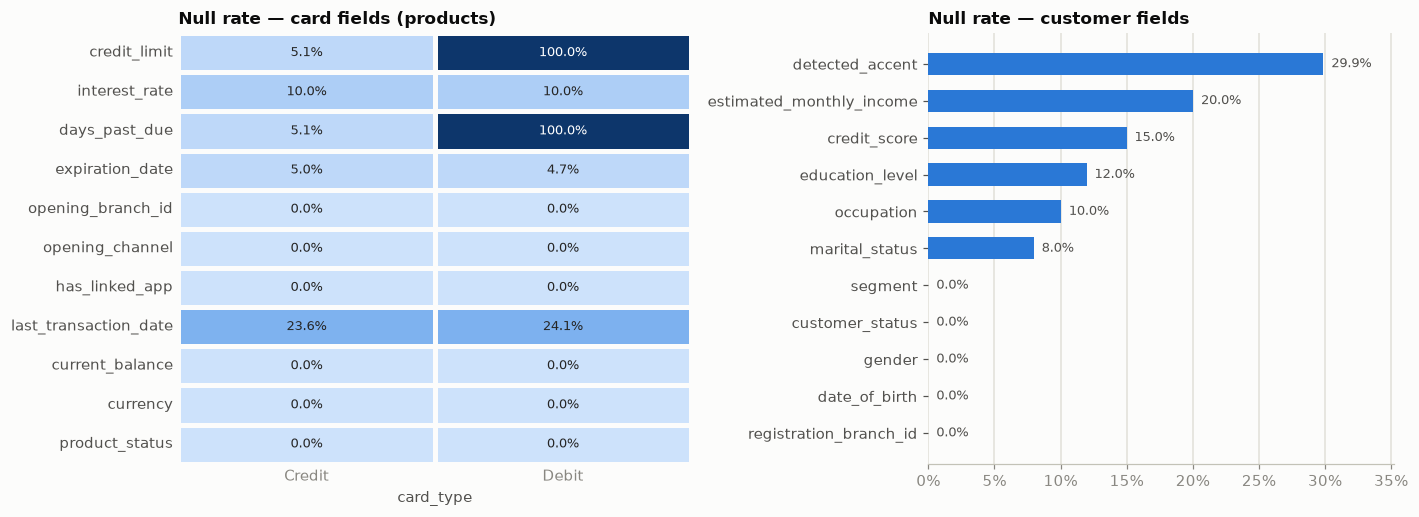

In [11]:
card_cols = ["credit_limit", "interest_rate", "days_past_due", "expiration_date", "opening_branch_id",
             "opening_channel", "has_linked_app", "last_transaction_date", "current_balance", "currency", "product_status"]
null_rates = sql(f"""
SELECT card_type, {', '.join(f"avg(({c} IS NULL)::INT) AS {c}" for c in card_cols)}
FROM cards GROUP BY card_type ORDER BY card_type
""").set_index("card_type").T

cust_cols = ["segment", "credit_score", "estimated_monthly_income", "detected_accent", "occupation",
             "marital_status", "education_level", "customer_status", "gender", "date_of_birth", "registration_branch_id"]
cust_nulls = sql(f"SELECT {', '.join(f'avg(({c} IS NULL)::INT) AS {c}' for c in cust_cols)} FROM customers").T
cust_nulls.columns = ["null_rate"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.1, 1]})
heat(axes[0], null_rates, title="Null rate — card fields (products)")
hbar(axes[1], cust_nulls.null_rate.sort_values(ascending=False), kind="pct", title="Null rate — customer fields")
plt.tight_layout()

Structural nulls are expected: debit cards have no credit limit and no days past due.
Non-structural fields sit around the documented ~5%, except the customer fields called out below.

In [12]:
last_tx_null_by_status = sql("""
SELECT product_status, count(*) AS cards, avg((last_transaction_date IS NULL)::INT) AS no_last_tx_rate
FROM cards GROUP BY 1 ORDER BY cards DESC""")
pct_table(last_tx_null_by_status, ["no_last_tx_rate"])

,product_status,cards,no_last_tx_rate
0,Active,"118,839",0.101255
1,Closed,"11,297",1.000000
2,Blocked,"7,044",1.000000
3,Suspended,"2,860",1.000000


In [13]:
note("Data quality", f"customers.estimated_monthly_income is null for {cust_nulls.loc['estimated_monthly_income','null_rate']:.0%} and "
     f"detected_accent for {cust_nulls.loc['detected_accent','null_rate']:.0%} of customers (well above the documented ~5%).",
     "Income-based eligibility and accent-based routing must handle 'unknown' explicitly.")
note("Data quality", "Every Closed, Blocked and Suspended card has a null last_transaction_date, and (see §6) none of them has a single transaction; "
     f"{last_tx_null_by_status.set_index('product_status').loc['Active','no_last_tx_rate']:.0%} of Active cards also lack one.",
     "There is no history explaining *why* a card was blocked or closed; the synthetic policy must supply block reasons.")

### 1.5 Temporal consistency

In [14]:
temporal = sql(f"""
SELECT 'cards' AS unit, 'last_updated after as-of date (future)' AS check_name,
       count(*) FILTER (WHERE last_updated > TIMESTAMP '{AS_OF} 23:59:59') AS n, count(*) AS total FROM cards
UNION ALL SELECT 'cards', 'expiration_date before opening_date', count(*) FILTER (WHERE expiration_date < opening_date), count(*) FROM cards
UNION ALL SELECT 'cards', 'last_transaction_date before opening_date', count(*) FILTER (WHERE last_transaction_date < opening_date), count(*) FROM cards
UNION ALL SELECT 'cards', 'last_updated before opening_date', count(*) FILTER (WHERE CAST(last_updated AS DATE) < opening_date), count(*) FROM cards
UNION ALL SELECT 'card transactions', 'dated before the card opening_date', count(*) FILTER (WHERE CAST(transaction_date AS DATE) < opening_date), count(*) FROM card_tx
UNION ALL SELECT 'card transactions', 'dated after the card expiration_date', count(*) FILTER (WHERE CAST(transaction_date AS DATE) > expiration_date), count(*) FROM card_tx
UNION ALL SELECT 'customers', 'registration_date after as-of date', count(*) FILTER (WHERE registration_date > TIMESTAMP '{AS_OF} 23:59:59'), count(*) FROM customers
""")
temporal["share"] = temporal.n / temporal.total
pct_table(temporal, ["share"])

,unit,check_name,n,total,share
0,cards,last_updated after as-of date (future),"8,692","140,040",0.062068
1,cards,expiration_date before opening_date,0,"140,040",0.000000
2,cards,last_transaction_date before opening_date,0,"140,040",0.000000
3,cards,last_updated before opening_date,0,"140,040",0.000000
4,card transactions,dated before the card opening_date,"288,617","1,547,432",0.186514
5,card transactions,dated after the card expiration_date,"462,419","1,547,432",0.298830
6,customers,registration_date after as-of date,0,"150,000",0.000000


In [15]:
lag = sql("""
SELECT date_diff('day', CAST(transaction_date AS DATE), process_date) AS process_minus_tx_days,
       count(*) AS n, count(*) / sum(count(*)) OVER () AS share,
       min(hour(transaction_date)) AS min_hour, max(hour(transaction_date)) AS max_hour
FROM transactions GROUP BY 1 ORDER BY 1""")
pct_table(lag, ["share"])

,process_minus_tx_days,n,share,min_hour,max_hour
0,-1,"1,106,307",0.250012,0,6
1,0,"3,318,701",0.749988,6,23


`process_date` is one day *before* the calendar date of `transaction_date` for every transaction stamped between 00:00 and 05:59.
That pattern fits `transaction_date` being stored in UTC and `process_date` in local time (UTC−6, Mexico City).
It is not a late arrival: no record has `process_date` after the transaction date.

In [16]:
tq = temporal.set_index("check_name")
note("Data quality", f"{tq.loc['last_updated after as-of date (future)','n']:,} cards ({tq.loc['last_updated after as-of date (future)','share']:.1%}) have last_updated in the future (up to 2027).",
     "Treat last_updated as unreliable; do not use it to explain 'when did my card change'.")
note("Data quality", f"{tq.loc['dated before the card opening_date','n']:,} card transactions ({tq.loc['dated before the card opening_date','share']:.0%}) are dated before the card was opened.",
     "Transaction history and card lifecycle are generated independently; never infer a card's age or activation from its transactions.")
note("Data quality", "process_date = transaction_date − 1 day for ~25% of rows (00:00–05:59 timestamps): a UTC vs. local-time offset, not late data.",
     "Show customers the local transaction date; convert timestamps consistently before comparing with statements.")
note("Data quality", f"{tq.loc['dated after the card expiration_date','n']:,} card transactions ({tq.loc['dated after the card expiration_date','share']:.0%}) are dated after the card's expiration date, most of them Approved.",
     "The agent cannot assume an expired card stops transacting; see the response-code analysis in §6.")

### 1.6 Currency vs. country

In [17]:
cur = sql("""
SELECT country, card_type, currency, count(*) AS cards
FROM cards GROUP BY ALL ORDER BY country, card_type, currency""").pivot_table(
    index=["country", "card_type"], columns="currency", values="cards", fill_value=0)
cur

currency                   ARS        COP        USD
country   card_type                                 
Argentina Credit    17,831.000      0.000  2,045.000
          Debit      7,254.000      0.000    737.000
Colombia  Credit         0.000 27,035.000  3,035.000
          Debit          0.000 10,841.000  1,250.000
México    Credit         0.000      0.000 50,156.000
          Debit          0.000      0.000 19,856.000

In [18]:
tx_cur = sql("SELECT currency, count(*) AS n, count(amount_usd) AS with_amount_usd FROM transactions GROUP BY 1 ORDER BY 1")
tx_cur

,currency,n,with_amount_usd
0,ARS,792585,752544
1,COP,1194444,1135008
2,USD,2437979,0


In [19]:
note("Data quality", "There is no MXN anywhere in products or transactions: every Mexican card is denominated in USD, "
     "while Mexican incomes are in MXN.", "Present Mexican balances in USD as stored; convert with daily_exchange_rates when comparing with income.")
note("Data quality", "transactions.amount_usd is null for all USD rows and ~5% of ARS/COP rows.",
     "Fill amount_usd = amount for USD and use the daily FX rate otherwise (done in card_tx.amount_usd_filled).")

### 1.7 Encoding checks

In [20]:
enc = pd.concat({
    "document_type × country": sql("SELECT country, document_type, count(*) n FROM customers GROUP BY ALL ORDER BY ALL").set_index(["country", "document_type"]).n,
}, names=["check"])
display(enc.to_frame())
display(sql("SELECT days_past_due, count(*) AS credit_cards FROM cards WHERE card_type='Credit' GROUP BY 1 ORDER BY 1"))
display(sql("SELECT term_months, count(*) AS cards FROM cards GROUP BY 1 ORDER BY 2 DESC LIMIT 8"))

n
check                   country   document_type       
document_type × country Argentina DNI            29842
                        Colombia  CC             15039
                                  CE             15150
                                  Pasaporte      15062
                        México    DNI            74907

,days_past_due,credit_cards
0,0.000,80831
1,15.000,2354
2,30.000,2346
3,60.000,2383
4,90.000,2447
5,120.000,2311
6,180.000,2361
7,NaN,5069


,term_months,cards
0,36,43371
1,48,43022
2,60,42354
3,<NA>,6879
4,59,1898
5,47,1441
6,35,1075


In [21]:
note("Data quality", "Mexican customers all carry document_type 'DNI' (Mexico uses CURP/INE). Colombian CC, CE and Passport are plausible.",
     "Identity verification must not validate document formats by country using this field.")
note("Data quality", "days_past_due only takes 7 values (0, 15, 30, 60, 90, 120, 180): it is a bucket, not a day count.",
     "Communicate delinquency as a bucket ('more than 30 days'), never as an exact day count.")

**Section 1 — key takeaways** *(the Findings register in §9 has the complete list)*
- **Structurally clean:** no duplicate keys, no content duplicates and no orphan foreign keys in the core joins, and every table keeps a single header across all 1,097 daily files. The documented ~2% duplicates and schema evolution are **not present** in this delivery.
- **Row counts differ from the dictionary:** transactions 88%, interactions 86%, transcripts 86%, complaints 84%, digital_events **156%**.
- **The real problems are semantic:** future `last_updated` values, transactions dated before card opening or after expiration, no MXN (Mexican cards are in USD), Mexican customers typed `DNI`, a UTC-vs-local `process_date` shift, and days past due stored as a 7-value bucket.
- `mentioned_products` is 99% orphan IDs, so interactions can only be linked to cards through the customer.

## 2. Card portfolio

In [21]:
kpi = sql("""
SELECT count(*) AS cards,
       count(*) FILTER (WHERE card_type='Credit') AS credit_cards,
       count(*) FILTER (WHERE card_type='Debit') AS debit_cards,
       count(DISTINCT customer_id) AS cardholders,
       count(DISTINCT customer_id) / (SELECT count(*) FROM customers) AS cardholder_share,
       avg((product_status='Active')::INT) AS active_share
FROM cards""")
pct_table(kpi, ["cardholder_share", "active_share"])

,cards,credit_cards,debit_cards,cardholders,cardholder_share,active_share
0,"140,040","100,102","39,938","91,084",0.607227,0.848608


card_type,Credit,Debit
product_status,,
Active,85090,33749
Closed,8053,3244
Blocked,4932,2112
Suspended,2027,833


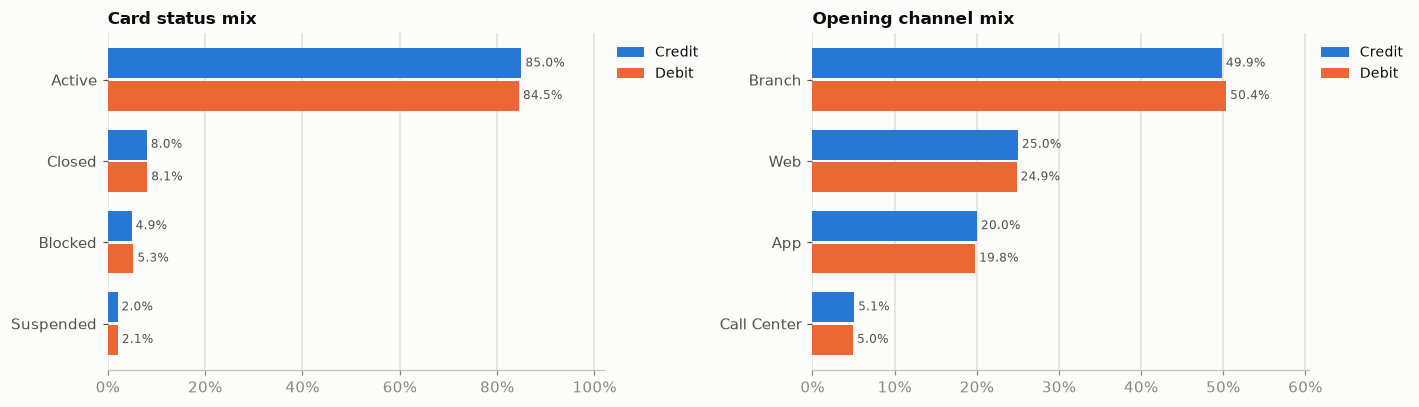

In [23]:
status = sql("SELECT product_status, card_type, count(*) n FROM cards GROUP BY ALL").pivot_table(
    index="product_status", columns="card_type", values="n").loc[["Active", "Closed", "Blocked", "Suspended"]]
status_share = status / status.sum()
chan = sql("SELECT opening_channel, card_type, count(*) n FROM cards GROUP BY ALL").pivot_table(
    index="opening_channel", columns="card_type", values="n")
chan_share = (chan / chan.sum()).sort_values("Credit", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
grouped_hbar(axes[0], status_share, CARD_COLORS, kind="pct", title="Card status mix")
grouped_hbar(axes[1], chan_share, CARD_COLORS, kind="pct", title="Opening channel mix")
plt.tight_layout()
display(status.astype(int))

,card_type,linked_app_rate
0,Credit,0.500220
1,Debit,0.496520


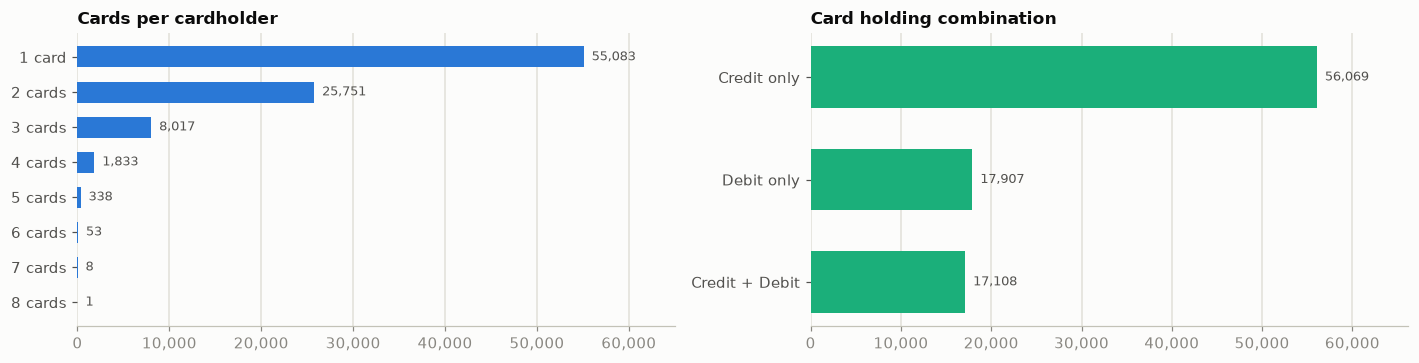

In [24]:
app = sql("SELECT card_type, avg(has_linked_app::INT) AS linked_app_rate FROM cards GROUP BY 1 ORDER BY 1")
cpc = sql("""
SELECT n_cards, count(*) AS customers FROM (SELECT customer_id, count(*) n_cards FROM cards GROUP BY 1)
GROUP BY 1 ORDER BY 1""")
combo = sql("""
SELECT CASE WHEN c>0 AND d>0 THEN 'Credit + Debit' WHEN c>0 THEN 'Credit only' ELSE 'Debit only' END AS holding,
       count(*) AS customers
FROM (SELECT customer_id, count(*) FILTER (WHERE card_type='Credit') c, count(*) FILTER (WHERE card_type='Debit') d FROM cards GROUP BY 1)
GROUP BY 1 ORDER BY 2 DESC""")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
hbar(axes[0], cpc.set_index("n_cards").customers.rename(lambda i: f"{i} card{'s' if i > 1 else ''}"), title="Cards per cardholder")
hbar(axes[1], combo.set_index("holding").customers, color=C["aqua"], title="Card holding combination")
plt.tight_layout()
pct_table(app, ["linked_app_rate"])

### 2.1 Vintage and term

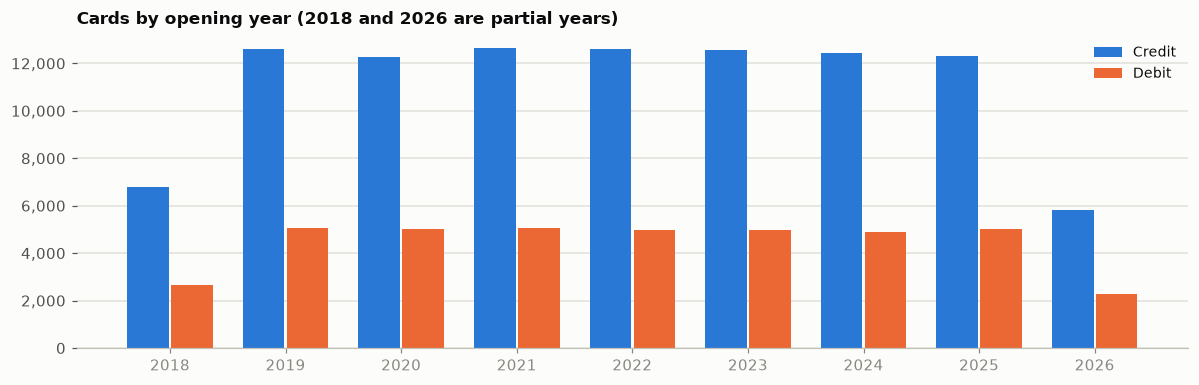

In [25]:
vint = sql("SELECT open_year, card_type, count(*) n FROM cards GROUP BY ALL").pivot_table(index="open_year", columns="card_type", values="n")
fig, ax = plt.subplots(figsize=(11, 3.6))
x = np.arange(len(vint))
for i, col in enumerate(vint.columns):
    ax.bar(x + (i - 0.5) * 0.38, vint[col], width=0.36, color=CARD_COLORS[col], label=col)
ax.set_xticks(x, vint.index)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.grid(axis="x", visible=False)
ax.set_title("Cards by opening year (2018 and 2026 are partial years)")
ax.legend()
plt.tight_layout()

### 2.2 Expiration and replacement demand
Expiration is measured against the as-of date. Cards expiring soon, and expired cards still marked Active,
are the main source of *"my card is expiring / when do I get the new one?"* requests.

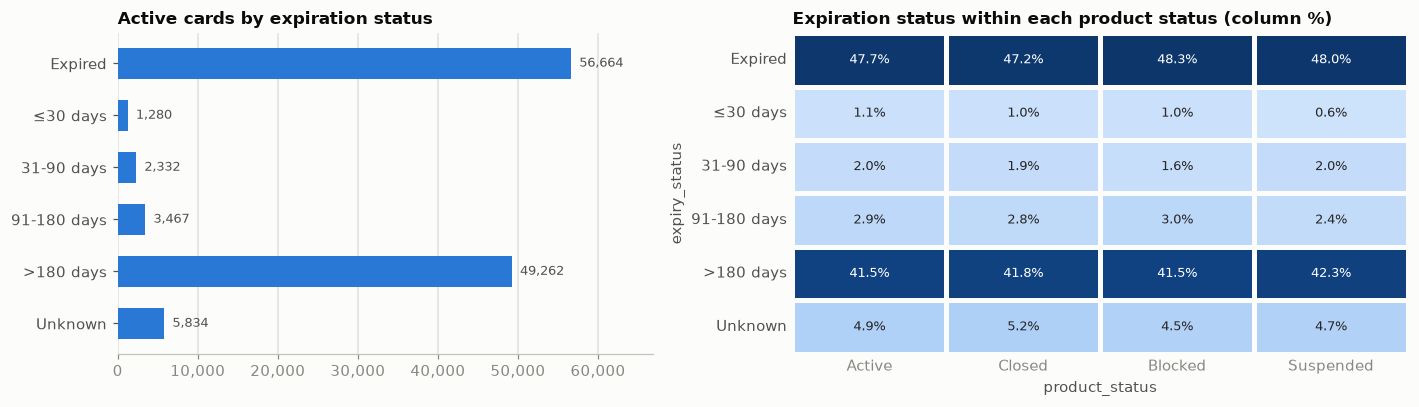

In [26]:
exp_order = ["Expired", "≤30 days", "31-90 days", "91-180 days", ">180 days", "Unknown"]
exp = sql("SELECT expiry_status, product_status, count(*) n FROM cards GROUP BY ALL").pivot_table(
    index="expiry_status", columns="product_status", values="n", fill_value=0).reindex(exp_order)[["Active", "Closed", "Blocked", "Suspended"]]
exp_share = exp.div(exp.sum(axis=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 1.15]})
hbar(axes[0], exp["Active"], title="Active cards by expiration status")
heat(axes[1], exp_share, title="Expiration status within each product status (column %)")
plt.tight_layout()

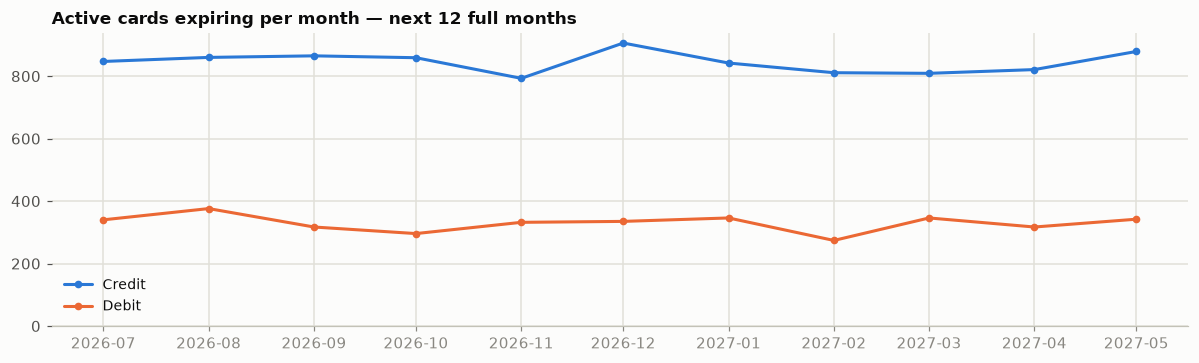

In [27]:
upcoming = sql(f"""
SELECT date_trunc('month', expiration_date) AS month, card_type, count(*) n
FROM cards WHERE product_status='Active' AND expiration_date >= DATE '{AS_OF}'
  AND expiration_date < DATE '{AS_OF}' + INTERVAL 12 MONTH
GROUP BY ALL""").pivot_table(index="month", columns="card_type", values="n").iloc[1:-1]  # drop partial months
fig, ax = plt.subplots(figsize=(11, 3.4))
for col in upcoming.columns:
    ax.plot(upcoming.index, upcoming[col], color=CARD_COLORS[col], label=col, marker="o", markersize=4)
ax.set_title("Active cards expiring per month — next 12 full months")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_ylim(0)
ax.legend()
plt.tight_layout()

In [28]:
active_expired = exp.loc["Expired", "Active"] / exp["Active"].sum()
note("Portfolio", f"{active_expired:.0%} of Active cards ({int(exp.loc['Expired','Active']):,}) are past their expiration date as of {AS_OF}.",
     "Status 'Active' does not mean the plastic is usable; the agent must check expiration_date and offer replacement.")

**Section 2 — key takeaways**
- **140,040 cards** (100,102 credit, 39,938 debit) held by 91,084 customers (61% of the base). 85% are Active, and the status mix is the same for credit and debit.
- Branch is the main opening channel (~50%), followed by Web (~25%) and App (~20%). Half of the cards have a linked app.
- 60% of cardholders have one card and 40% have two or more, so the agent must always confirm *which* card.
- Terms are 36/48/60 months. **48% of Active cards are already expired** and ~1.2K more expire each month, making expiration and replacement a high-volume, well-grounded intent.

## 3. Cardholder & customer profile

In [29]:
seg = sql("""
SELECT segment, count(*) AS customers,
       avg(credit_score) AS avg_credit_score, median(income_usd) AS median_income_usd, median(age) AS median_age
FROM customers GROUP BY 1 ORDER BY customers DESC""")
seg

,segment,customers,avg_credit_score,median_income_usd,median_age
0,Basic,89756,599.537,"1,793.415",53.000
1,Plus,37547,699.183,"6,700.062",53.000
2,Premium,15207,797.404,"17,947.394",52.000
3,Student,7490,649.020,671.847,52.000


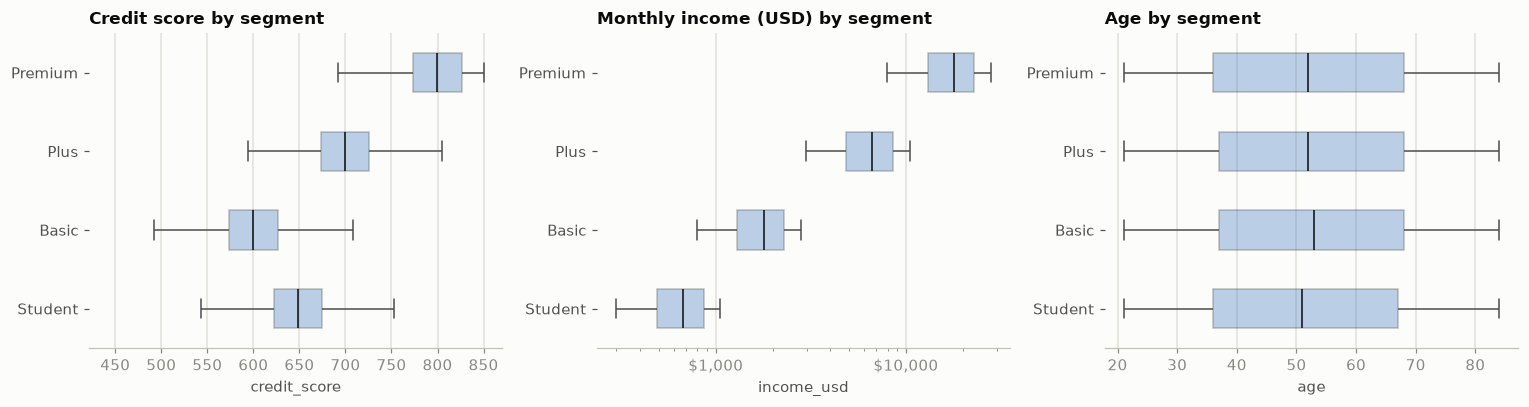

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
order = ["Premium", "Plus", "Basic", "Student"]
d = sql("SELECT segment, credit_score, income_usd, age FROM customers USING SAMPLE 40000 ROWS (reservoir, 7)")
for ax, col, title in zip(axes, ["credit_score", "income_usd", "age"],
                          ["Credit score by segment", "Monthly income (USD) by segment", "Age by segment"]):
    sns.boxplot(data=d, y="segment", x=col, order=order, ax=ax, color=C["blue"], width=0.5, fliersize=0,
                boxprops={"alpha": 0.35}, medianprops={"color": INK})
    ax.set_title(title)
    ax.set_ylabel("")
    ax.grid(axis="y", visible=False)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.tight_layout()

### 3.1 Card penetration

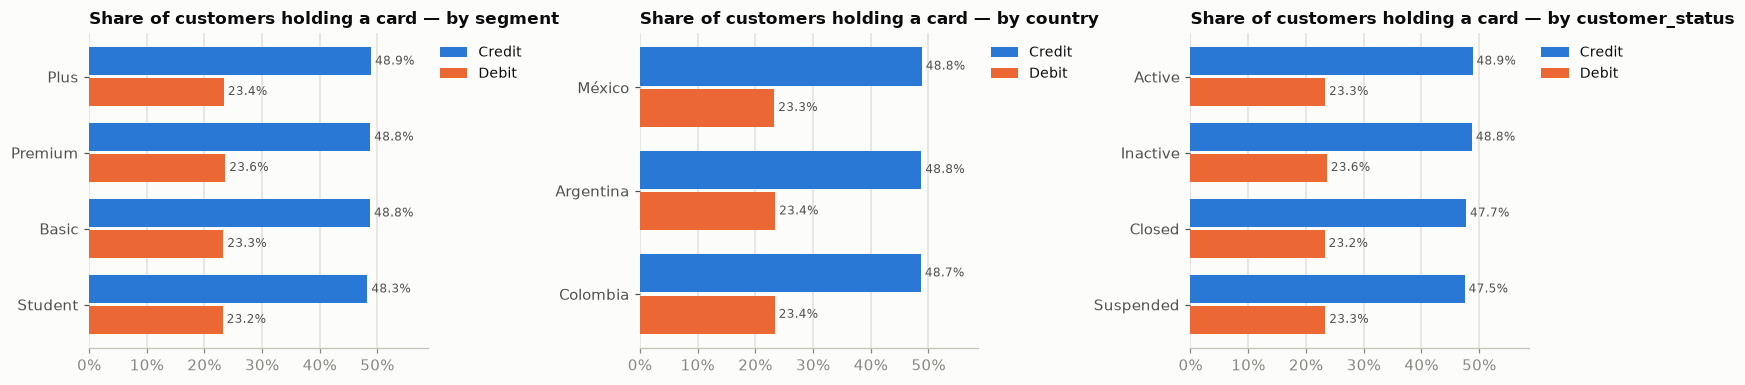

In [31]:
pen = sql("""
WITH h AS (SELECT customer_id,
                  bool_or(card_type='Credit') AS has_credit, bool_or(card_type='Debit') AS has_debit
           FROM cards GROUP BY 1)
SELECT c.segment, c.country, c.customer_status,
       coalesce(h.has_credit, false) AS has_credit, coalesce(h.has_debit, false) AS has_debit
FROM customers c LEFT JOIN h USING (customer_id)""")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, dim in zip(axes, ["segment", "country", "customer_status"]):
    t = pen.groupby(dim)[["has_credit", "has_debit"]].mean().rename(columns={"has_credit": "Credit", "has_debit": "Debit"})
    grouped_hbar(ax, t.sort_values("Credit", ascending=False), CARD_COLORS, kind="pct", title=f"Share of customers holding a card — by {dim}")
plt.tight_layout()

In [32]:
geo = sql("""
SELECT c.country, count(DISTINCT c.customer_id) AS customers, count(DISTINCT k.customer_id) AS cardholders,
       count(k.product_id) FILTER (WHERE k.card_type='Credit') AS credit_cards,
       count(k.product_id) FILTER (WHERE k.card_type='Debit') AS debit_cards
FROM customers c LEFT JOIN cards k USING (customer_id) GROUP BY 1 ORDER BY customers DESC""")
geo

,country,customers,cardholders,credit_cards,debit_cards
0,México,74907,45453,50156,19856
1,Colombia,45251,27503,30070,12091
2,Argentina,29842,18128,19876,7991


### 3.2 Customer status vs. card status
Can a customer who is Closed or Suspended still hold an Active card? For the agent this decides whether to trust the card status or the customer status.

product_status,Active,Closed,Blocked,Suspended
customer_status,,,,
Active,"101,364.000","9,558.000","6,005.000","2,405.000"
Closed,"2,307.000",203.000,146.000,60.000
Inactive,"11,750.000","1,206.000",668.000,316.000
Suspended,"3,418.000",330.000,225.000,79.000


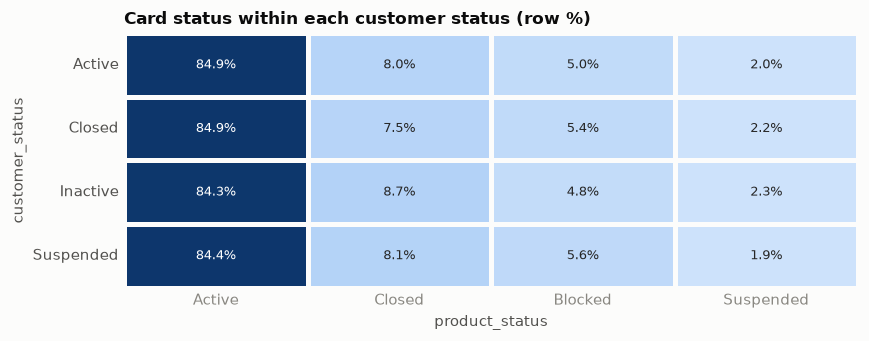

In [33]:
cs = sql("SELECT customer_status, product_status, count(*) n FROM cards GROUP BY ALL").pivot_table(
    index="customer_status", columns="product_status", values="n", fill_value=0)[["Active", "Closed", "Blocked", "Suspended"]]
fig, ax = plt.subplots(figsize=(8, 3.2))
heat(ax, cs.div(cs.sum(axis=1), axis=0), title="Card status within each customer status (row %)")
plt.tight_layout()
display(cs)

In [34]:
closed_active = cs.loc[["Closed", "Suspended", "Inactive"], "Active"].sum()
note("Customers", f"{int(closed_active):,} Active cards belong to Closed, Suspended or Inactive customers; card and customer status are independent.",
     "Define a precedence rule (e.g. customer Closed/Suspended ⇒ treat card as not usable) in the synthetic policy.")

In [35]:
acc = sql("SELECT country, coalesce(detected_accent,'(null)') AS detected_accent, count(*) n FROM customers GROUP BY ALL").pivot_table(
    index="country", columns="detected_accent", values="n", fill_value=0)
acc

detected_accent,(null),argentine,colombian,mexican
country,,,,
Argentina,"8,830.000","21,012.000",0.000,0.000
Colombia,"13,585.000",0.000,"31,666.000",0.000
México,"22,402.000",0.000,0.000,"52,505.000"


**Section 3 — key takeaways**
- Segments: Basic 60%, Plus 25%, Premium 10%, Student 5%. They differ clearly in credit score (≈600 / 700 / 800 / 650) and median monthly income (≈$1.8K / $6.7K / $17.9K / $0.7K USD).
- **Card penetration is flat:** ~49% of customers hold a credit card and ~23% a debit card, in every segment, country and customer status.
- Customer status and card status are independent: 17.5K Active cards belong to Closed, Suspended or Inactive customers, so a precedence rule is needed.
- ~30% of customers have no detected accent; accent always matches country when present.

## 4. Credit-card terms & risk
Credit cards only. Limits and balances are converted to USD at the as-of rate.

In [36]:
terms = sql("""
SELECT currency, count(*) AS cards,
       median(credit_limit) AS median_limit_local, median(limit_usd) AS median_limit_usd,
       median(balance_usd) AS median_balance_usd, median(utilization) AS median_util,
       avg(interest_rate) AS avg_interest_rate
FROM cards WHERE card_type='Credit' GROUP BY 1 ORDER BY cards DESC""")
terms

,currency,cards,median_limit_local,median_limit_usd,median_balance_usd,median_util,avg_interest_rate
0,USD,55236,"25,600.090","25,600.090","1,500.685",0.059,31.520
1,COP,27035,"101,755,070.120","25,235.257","1,494.020",0.059,31.548
2,ARS,17831,"8,948,046.645","25,707.738","1,508.647",0.059,31.385


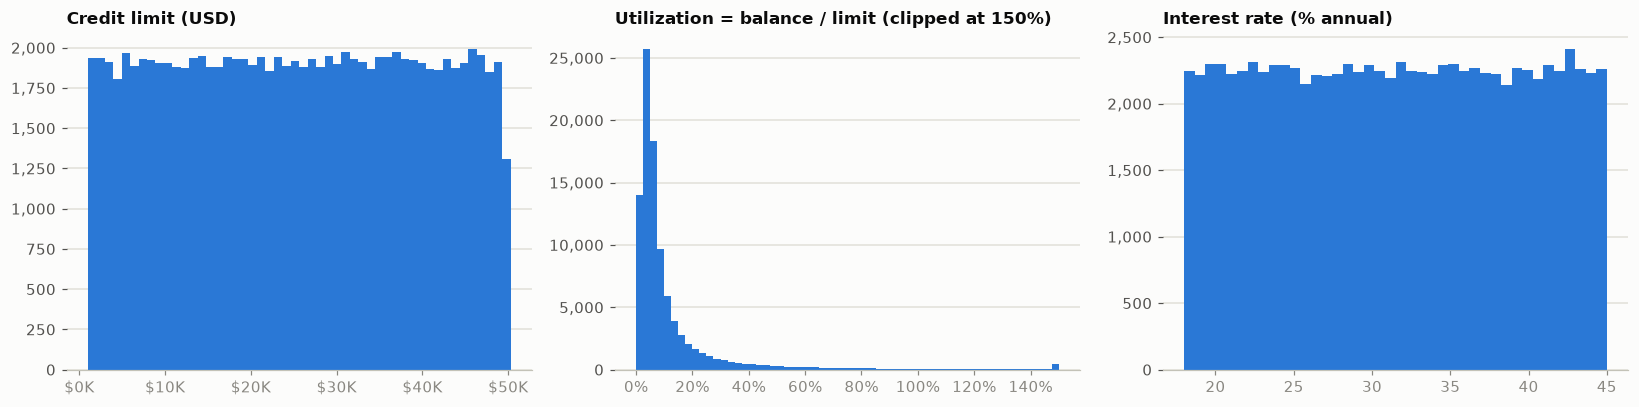

In [37]:
cc = sql("""SELECT segment, score_band, country, product_status, dpd_bucket, days_past_due, open_year,
                   limit_usd, balance_usd, utilization, interest_rate, credit_score, income_usd
            FROM cards WHERE card_type='Credit'""")
cc["limit_to_income"] = cc.limit_usd / cc.income_usd

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(cc.limit_usd.dropna(), bins=50, color=C["blue"])
axes[0].set_title("Credit limit (USD)")
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K"))
axes[1].hist(cc.utilization.dropna().clip(upper=1.5), bins=60, color=C["blue"])
axes[1].set_title("Utilization = balance / limit (clipped at 150%)")
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].hist(cc.interest_rate.dropna(), bins=40, color=C["blue"])
axes[2].set_title("Interest rate (% annual)")
for ax in axes:
    ax.grid(axis="x", visible=False)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
plt.tight_layout()

In [38]:
util_bands = pd.cut(cc.utilization, [-0.01, 0.1, 0.3, 0.5, 0.8, 1.0, np.inf],
                    labels=["0–10%", "10–30%", "30–50%", "50–80%", "80–100%", ">100% (over limit)"])
util_tbl = util_bands.value_counts(normalize=True).sort_index().rename("share").to_frame()
util_tbl["cards"] = util_bands.value_counts().sort_index()
pct_table(util_tbl, ["share"])

,share,cards
utilization,,
0–10%,0.711730,"67,645"
10–30%,0.205149,"19,498"
30–50%,0.041045,"3,901"
50–80%,0.022032,"2,094"
80–100%,0.007386,702
>100% (over limit),0.012657,"1,203"


### 4.1 Do customer attributes drive card terms?
If a risk model were behind the synthetic data, limits and rates would respond to credit score, income and segment.

In [39]:
drv = cc.groupby("score_band").agg(cards=("limit_usd", "size"), median_limit_usd=("limit_usd", "median"),
                                   avg_interest=("interest_rate", "mean"), median_util=("utilization", "median"),
                                   dpd_rate=("days_past_due", lambda s: (s > 0).mean()))
drv_seg = cc.groupby("segment").agg(cards=("limit_usd", "size"), median_limit_usd=("limit_usd", "median"),
                                    median_limit_to_income=("limit_to_income", "median"),
                                    avg_interest=("interest_rate", "mean"), dpd_rate=("days_past_due", lambda s: (s > 0).mean()))
display(pct_table(drv, ["dpd_rate"]))
display(pct_table(drv_seg, ["dpd_rate"]).format({"median_limit_to_income": "{:.1f}x"}))

,cards,median_limit_usd,avg_interest,median_util,dpd_rate
score_band,,,,,
1 Poor (<580),"15,996","25,239",31,0,0.143973
2 Fair (580-669),"40,955","25,545",31,0,0.142791
3 Good (670-739),"17,014","25,300",32,0,0.142177
4 Very good (740-799),"6,893","25,336",32,0,0.138982
5 Exceptional (800+),"4,467","25,449",32,0,0.132527
Unknown,"14,777","26,011",32,0,0.140895


,cards,median_limit_usd,median_limit_to_income,avg_interest,dpd_rate
segment,,,,,
Basic,59917,25499.694770,14.2x,31.483081,0.141212
Plus,25138,25502.975721,3.8x,31.550454,0.144801
Premium,10098,25408.657625,1.4x,31.595558,0.137057
Student,4949,25870.240000,38.5x,31.324809,0.144878


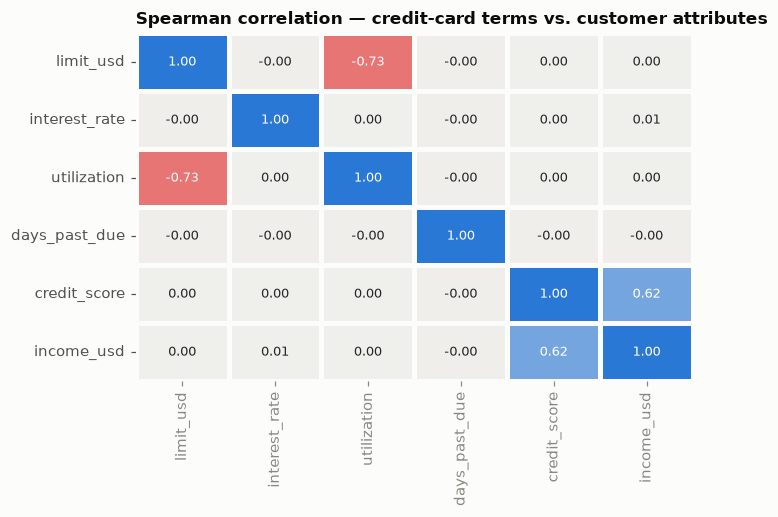

In [40]:
corr = cc[["limit_usd", "interest_rate", "utilization", "days_past_due", "credit_score", "income_usd"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 4.8))
sns.heatmap(corr, ax=ax, cmap=sns.blend_palette(["#e34948", "#f0efec", "#2a78d6"], as_cmap=True), vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=2, linecolor=SURFACE, cbar=False, annot_kws={"fontsize": 8.5})
ax.grid(False)
ax.set_title("Spearman correlation — credit-card terms vs. customer attributes")
plt.tight_layout()

In [41]:
lti = drv_seg.median_limit_to_income
note("Credit risk", "Credit limit (median ≈ $25.5K USD), interest rate (18–45%, mean ≈ 31.5%), utilization and days past due are independent of "
     f"credit score, income and segment (|Spearman ρ| < 0.02). Median limit-to-monthly-income is {lti['Premium']:.1f}x for Premium but {lti['Student']:.0f}x for Student.",
     "Credit-limit or rate explanations cannot be grounded in customer attributes; eligibility and limit-increase rules must come from a synthetic policy.")

### 4.2 Days past due

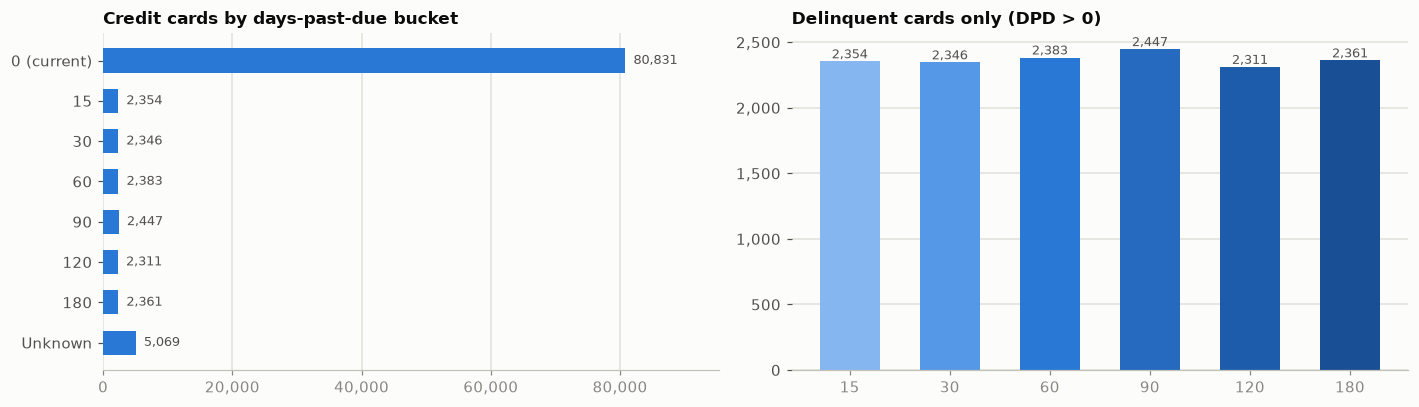

In [42]:
dpd_order = ["0 (current)", "15", "30", "60", "90", "120", "180", "Unknown"]
dpd = cc.dpd_bucket.value_counts().reindex(dpd_order)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
hbar(axes[0], dpd, title="Credit cards by days-past-due bucket")
late = dpd.drop(["0 (current)", "Unknown"])
bars = axes[1].bar(late.index, late.values, color=ORDINAL[:len(late)], width=0.6)
axes[1].set_title("Delinquent cards only (DPD > 0)")
axes[1].grid(axis="x", visible=False)
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
for b, v in zip(bars, late.values):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", color=INK2, fontsize=8.5)
plt.tight_layout()

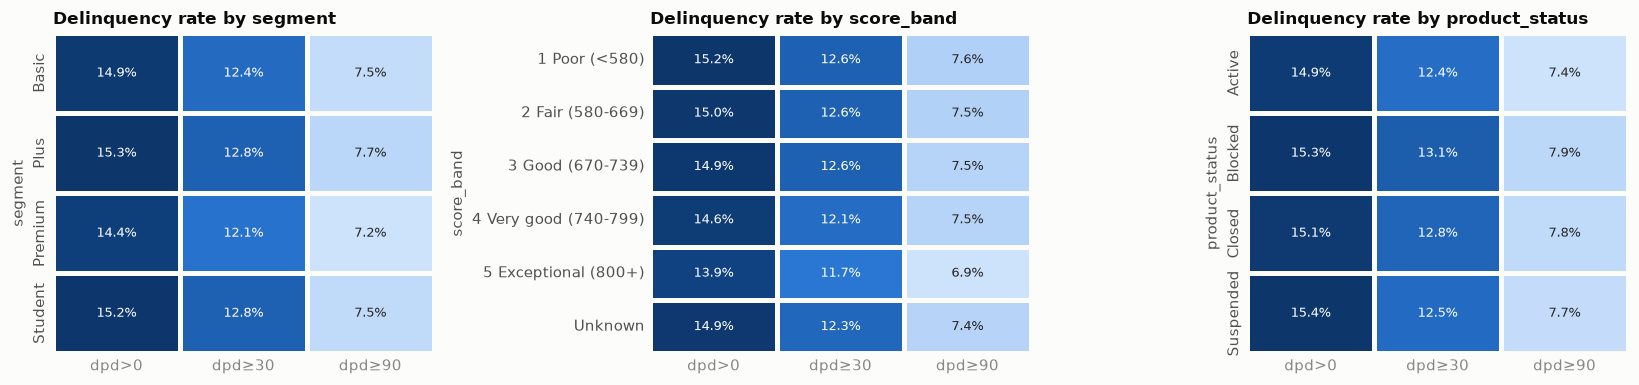

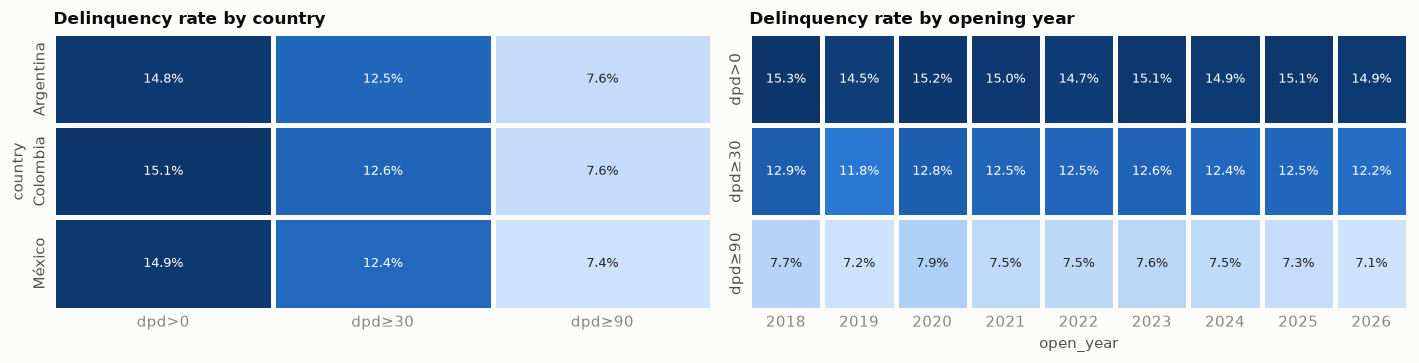

In [43]:
known = cc[cc.days_past_due.notna()]
rates = lambda g: pd.Series({"cards": len(g), "dpd>0": (g.days_past_due > 0).mean(),
                             "dpd≥30": (g.days_past_due >= 30).mean(), "dpd≥90": (g.days_past_due >= 90).mean()})
tbls = {dim: known.groupby(dim).apply(rates, include_groups=False) for dim in ["segment", "country", "score_band", "product_status", "open_year"]}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, dim in zip(axes, ["segment", "score_band", "product_status"]):
    heat(ax, tbls[dim][["dpd>0", "dpd≥30", "dpd≥90"]], title=f"Delinquency rate by {dim}")
plt.tight_layout()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
heat(axes[0], tbls["country"][["dpd>0", "dpd≥30", "dpd≥90"]], title="Delinquency rate by country")
heat(axes[1], tbls["open_year"][["dpd>0", "dpd≥30", "dpd≥90"]].T, title="Delinquency rate by opening year")
plt.tight_layout()

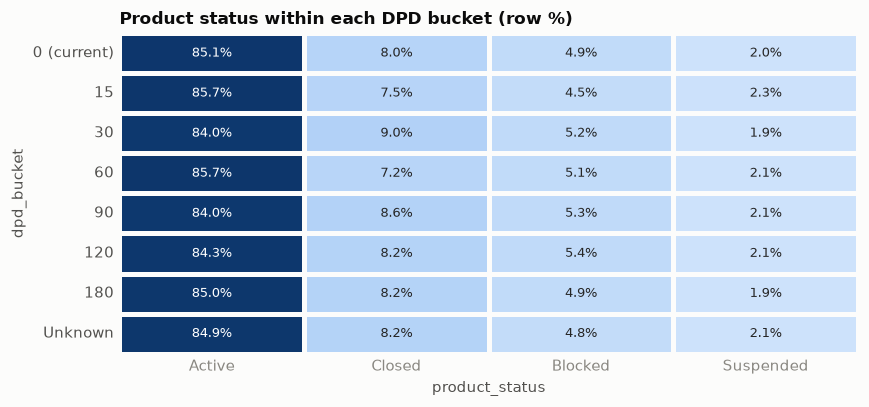

In [44]:
dpd_status = sql("""
SELECT dpd_bucket, product_status, count(*) n FROM cards WHERE card_type='Credit' GROUP BY ALL""").pivot_table(
    index="dpd_bucket", columns="product_status", values="n", fill_value=0).reindex(dpd_order)[["Active", "Closed", "Blocked", "Suspended"]]
fig, ax = plt.subplots(figsize=(8, 3.8))
heat(ax, dpd_status.div(dpd_status.sum(axis=1), axis=0), title="Product status within each DPD bucket (row %)")
plt.tight_layout()

In [45]:
bal_dpd = cc.groupby("dpd_bucket").agg(cards=("balance_usd", "size"), median_balance_usd=("balance_usd", "median"),
                                       median_util=("utilization", "median"), over_limit_rate=("utilization", lambda s: (s > 1).mean())).reindex(dpd_order)
pct_table(bal_dpd, ["over_limit_rate"]).format({"median_util": "{:.1%}"})

,cards,median_balance_usd,median_util,over_limit_rate
dpd_bucket,,,,
0 (current),80831,1502.110000,5.9%,0.011827
15,2354,1494.469268,6.0%,0.009771
30,2346,1507.630448,6.1%,0.011509
60,2383,1489.680000,5.9%,0.015527
90,2447,1477.826439,5.8%,0.013486
120,2311,1507.900000,5.8%,0.012116
180,2361,1503.620000,6.0%,0.011859
Unknown,5069,1480.550000,5.9%,0.014007


In [46]:
dq_rate = (known.days_past_due > 0).mean()
note("Credit risk", f"{dq_rate:.1%} of credit cards are past due and {(known.days_past_due >= 90).mean():.1%} are 90+ days; "
     "rates are flat across segment, score band, country, opening year and product status.",
     "Collections intents ('why is my card blocked / how much do I owe') are frequent; DPD does not explain Blocked/Suspended status, so the agent must not assume it does.")
note("Credit risk", f"{(cc.utilization.dropna() > 1).mean():.1%} of credit cards are over their limit (utilization > 100%).",
     "Over-limit is a real decline and fee driver to cover in the card-support policy.")

**Section 4 — key takeaways**
- Limits (≈ $0–50K USD) and interest rates (18–45%) are **uniformly distributed**, a synthetic-generator signature. The median limit is **≈ $25.5K USD in every currency**. Utilization is low (median 6%, 71% of cards below 10%, 1.3% over the limit).
- **Terms are not risk-based:** limit, rate, utilization and DPD are uncorrelated with credit score, income and segment (|ρ| < 0.02). A Student's median limit is ~39x their monthly income.
- **14.9% of credit cards are past due and 7.5% are 90+ days**. This is flat across segment, score band, country, opening year and product status, so DPD does not explain Blocked or Suspended cards.

## 5. Payments & payment timing

`products` has **no statement date, due date or minimum payment**. Payment behaviour has to be derived from
`transactions` where `transaction_type = 'Payment'` on a card.

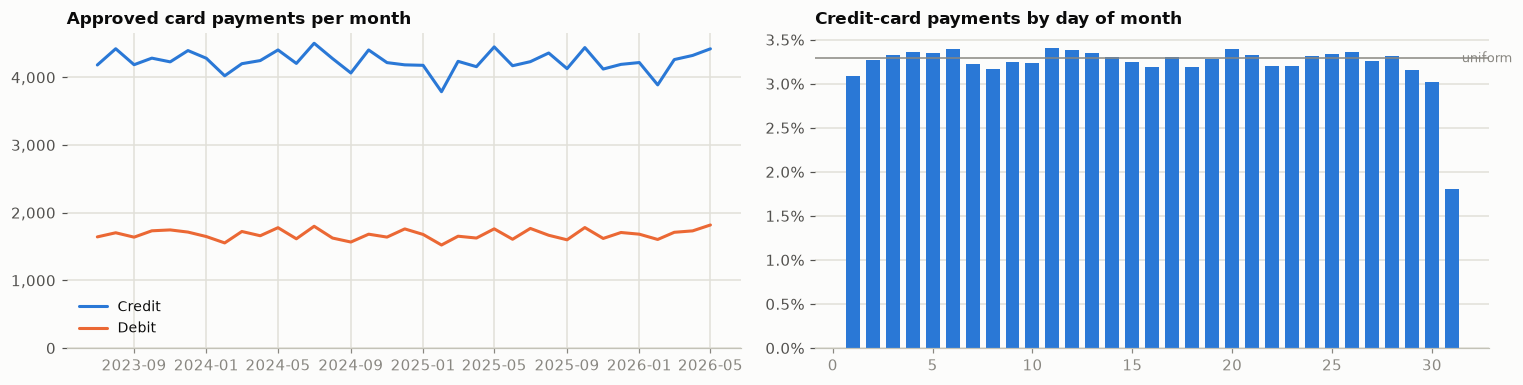

In [47]:
pay_month = sql("""
SELECT date_trunc('month', transaction_date) AS month, card_type,
       count(*) AS payments, sum(amount_usd_filled) AS amount_usd
FROM card_tx WHERE transaction_type='Payment' AND transaction_status='Approved'
GROUP BY ALL ORDER BY 1""")
pm = pay_month.pivot_table(index="month", columns="card_type", values="payments")
pm = pm.iloc[1:-1]  # drop partial first/last months
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6))
for col in pm.columns:
    axes[0].plot(pm.index, pm[col], color=CARD_COLORS[col], label=col)
axes[0].set_title("Approved card payments per month")
axes[0].set_ylim(0)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
axes[0].legend()
dom = sql("""SELECT day(transaction_date) AS day, count(*) n FROM card_tx
             WHERE transaction_type='Payment' AND card_type='Credit' GROUP BY 1 ORDER BY 1""").set_index("day").n
axes[1].bar(dom.index, dom.values / dom.sum(), color=C["blue"], width=0.7)
axes[1].axhline(1 / 30.4, color=MUTED, linewidth=1)
axes[1].text(31.5, 1 / 30.4, "uniform", color=MUTED, va="center", fontsize=8.5)
axes[1].set_title("Credit-card payments by day of month")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=1))
axes[1].grid(axis="x", visible=False)
plt.tight_layout()

Payments are spread evenly across the month, so there is no billing cycle or due-date peak in the data
(day 31 is lower only because fewer months have one).

In [48]:
pay_card = sql(f"""
WITH p AS (
  SELECT product_id, count(*) AS payments, max(transaction_date) AS last_payment,
         sum(amount_usd_filled) AS paid_usd
  FROM card_tx WHERE transaction_type='Payment' AND transaction_status='Approved' GROUP BY 1)
SELECT k.product_id, k.dpd_bucket, k.days_past_due, k.product_status, k.balance_usd, k.limit_usd,
       coalesce(p.payments, 0) AS payments, p.paid_usd,
       date_diff('day', CAST(p.last_payment AS DATE), DATE '{AS_OF}') AS days_since_last_payment,
       date_diff('month', greatest(k.opening_date, DATE '2023-06-17'), DATE '{AS_OF}') AS months_observed
FROM cards k LEFT JOIN p USING (product_id)
WHERE k.card_type='Credit'""")
pay_card["payments_per_year"] = pay_card.payments / (pay_card.months_observed.clip(lower=1) / 12)
by_dpd = pay_card.groupby("dpd_bucket").agg(
    cards=("product_id", "size"),
    never_paid_rate=("payments", lambda s: (s == 0).mean()),
    payments_per_year=("payments_per_year", "median"),
    median_days_since_last_payment=("days_since_last_payment", "median"),
    paid_last_30d_rate=("days_since_last_payment", lambda s: (s <= 30).mean()),
).reindex(dpd_order)
pct_table(by_dpd, ["never_paid_rate", "paid_last_30d_rate"]).format({"payments_per_year": "{:.1f}", "median_days_since_last_payment": "{:,.0f}"})

,cards,never_paid_rate,payments_per_year,median_days_since_last_payment,paid_last_30d_rate
dpd_bucket,,,,,
0 (current),80831,0.290260,0.7,329,0.060939
15,2354,0.292268,0.7,333,0.067827
30,2346,0.305627,0.5,323,0.052179
60,2383,0.276962,0.7,334,0.052234
90,2447,0.295872,0.6,311,0.059199
120,2311,0.292514,0.6,341,0.055657
180,2361,0.287166,0.7,328,0.062983
Unknown,5069,0.288814,0.6,342,0.061026


If DPD were derived from payments, cards at 90–180 DPD would show no recent payments. The table tests that.

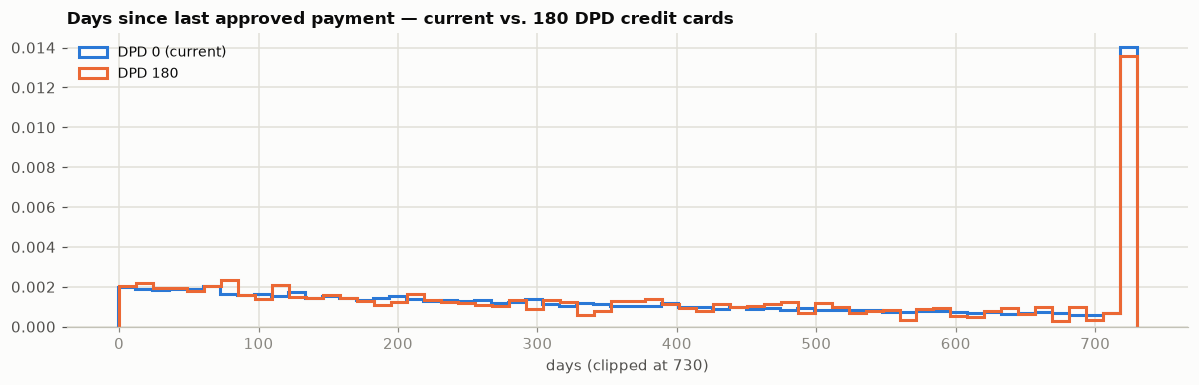

In [49]:
fig, ax = plt.subplots(figsize=(11, 3.6))
for bucket, color in [("0 (current)", C["blue"]), ("180", C["orange"])]:
    s = pay_card.loc[pay_card.dpd_bucket == bucket, "days_since_last_payment"].dropna()
    ax.hist(s.clip(upper=730), bins=60, density=True, histtype="step", linewidth=2, color=color, label=f"DPD {bucket}")
ax.set_title("Days since last approved payment — current vs. 180 DPD credit cards")
ax.set_xlabel("days (clipped at 730)")
ax.legend()
plt.tight_layout()

In [50]:
recency = sql(f"""
WITH m AS (SELECT product_id, max(transaction_date) AS max_tx FROM card_tx GROUP BY 1)
SELECT k.card_type, count(*) AS cards_with_both,
       avg((abs(date_diff('day', k.last_transaction_date, m.max_tx)) <= 1)::INT) AS match_within_1d_rate,
       median(date_diff('day', m.max_tx, k.last_transaction_date)) AS median_gap_days
FROM cards k JOIN m USING (product_id)
WHERE k.last_transaction_date IS NOT NULL GROUP BY 1""")
pct_table(recency, ["match_within_1d_rate"])

,card_type,cards_with_both,match_within_1d_rate,median_gap_days
0,Debit,"30,307",0.004091,-467
1,Credit,"76,499",0.004065,-473


In [51]:
debit_pay = sql("""SELECT transaction_type, count(*) n, median(amount_usd_filled) median_usd FROM card_tx
                   WHERE card_type='Debit' GROUP BY 1 ORDER BY n DESC""")
debit_pay

,transaction_type,n,median_usd
0,Purchase,307572,252.430
1,Payment,65796,"1,029.840"
2,Withdrawal,65779,260.540


In [52]:
paid_recent_180 = by_dpd.loc["180", "paid_last_30d_rate"]
note("Payments", "No due date, statement date or minimum-payment field exists, and payments are uniform across days of the month.",
     "'When is my payment due / what is my minimum' must come from a synthetic billing policy (e.g. cycle-based due date) that is labelled as such.")
note("Payments", f"Payment behaviour does not explain DPD: {paid_recent_180:.0%} of 180-DPD cards paid in the last 30 days vs. {by_dpd.loc['0 (current)','paid_last_30d_rate']:.0%} of current cards, "
     f"and ~{by_dpd.never_paid_rate.mean():.0%} of cards in every bucket never paid in 3 years.",
     "Do not compute or explain delinquency from transactions; report the stored DPD bucket and escalate disputes about it.")
note("Payments", f"products.last_transaction_date matches the latest transaction in the transactions table for only {recency.match_within_1d_rate.mean():.1%} of cards "
     f"(median gap {recency.median_gap_days.median():,.0f} days).",
     "Ground 'last movement' answers on the transactions table (the fact table) and document that choice.")
note("Payments", "Debit cards carry 'Payment' transactions (bill payments from the account), not card repayments.",
     "Intent handling must separate 'pay my credit card' from 'payments made with my debit card'.")

**Section 5 — key takeaways**
- There is **no due date, statement date or minimum payment**. Card payments (166K on credit cards, median ≈ $1K) are uniform across the days of the month, so a billing cycle has to be defined as synthetic policy.
- Payment behaviour is unrelated to DPD (same recency and same never-paid share, ~29%, in every bucket). `last_transaction_date` does not match the transactions table either.
- **Recommendation:** use the product snapshot as the source of truth for card *state* (status, balance, limit, DPD) and the transactions table for *movements*, and never derive one from the other.

## 6. Card transactions & authorizations

,card_type,transaction_type,n,median_usd
0,Credit,Purchase,775834,252.280
1,Credit,Withdrawal,166613,259.950
2,Credit,Payment,165838,"1,022.865"
3,Debit,Purchase,307572,252.430
4,Debit,Payment,65796,"1,029.840"
5,Debit,Withdrawal,65779,260.540


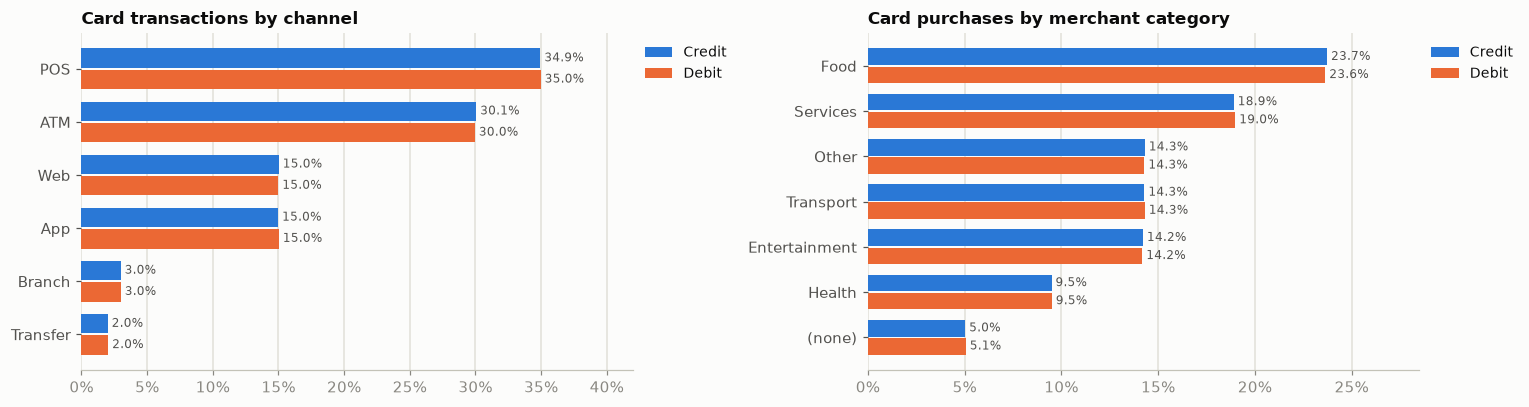

In [53]:
mix = sql("""SELECT card_type, transaction_type, count(*) n, median(amount_usd_filled) AS median_usd
             FROM card_tx GROUP BY ALL ORDER BY card_type, n DESC""")
display(mix)
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
chan_tx = sql("SELECT channel, card_type, count(*) n FROM card_tx GROUP BY ALL").pivot_table(index="channel", columns="card_type", values="n")
grouped_hbar(axes[0], (chan_tx / chan_tx.sum()).sort_values("Credit", ascending=False), CARD_COLORS, kind="pct", title="Card transactions by channel")
mcc = sql("SELECT coalesce(merchant_category,'(none)') mc, card_type, count(*) n FROM card_tx WHERE transaction_type='Purchase' GROUP BY ALL").pivot_table(
    index="mc", columns="card_type", values="n")
grouped_hbar(axes[1], (mcc / mcc.sum()).sort_values("Credit", ascending=False), CARD_COLORS, kind="pct", title="Card purchases by merchant category")
plt.tight_layout()

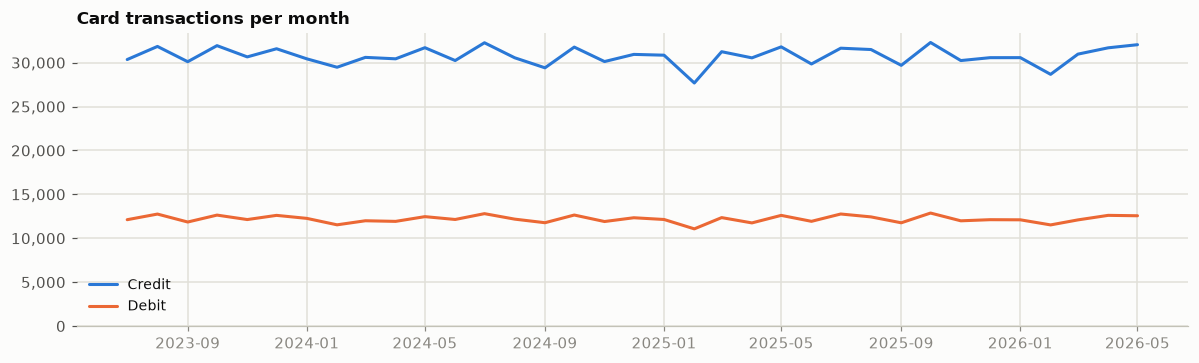

In [54]:
vol = sql("""SELECT date_trunc('month', transaction_date) m, card_type, count(*) n FROM card_tx GROUP BY ALL""").pivot_table(index="m", columns="card_type", values="n").iloc[1:-1]
fig, ax = plt.subplots(figsize=(11, 3.4))
for col in vol.columns:
    ax.plot(vol.index, vol[col], color=CARD_COLORS[col], label=col)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Card transactions per month")
ax.legend()
plt.tight_layout()

### 6.1 Authorization outcome and response codes
The codes are mapped to their usual ISO 8583 meaning. The dataset does not define them, so the mapping is our assumption.

In [55]:
RC = {"00": "Approved", "05": "Do not honor", "14": "Invalid card number", "51": "Insufficient funds", "54": "Expired card"}
st = sql("""SELECT transaction_status, coalesce(response_code,'(null)') AS response_code, count(*) n
            FROM card_tx GROUP BY ALL""").pivot_table(index="response_code", columns="transaction_status", values="n", fill_value=0)
st.index = [f"{i} — {RC.get(i, '')}" for i in st.index]
display(st[["Approved", "Declined", "Pending", "Reversed"]])
status_share = sql("SELECT transaction_status, count(*)/sum(count(*)) OVER () AS share FROM card_tx GROUP BY 1 ORDER BY 2 DESC")
pct_table(status_share, ["share"])

transaction_status,Approved,Declined,Pending,Reversed
(null) —,"70,923.000","3,816.000","1,566.000",829.000
00 — Approved,"1,352,125.000",0.000,0.000,0.000
05 — Do not honor,0.000,"18,404.000","7,409.000","3,767.000"
14 — Invalid card number,0.000,"18,534.000","7,418.000","3,778.000"
51 — Insufficient funds,0.000,"18,510.000","7,277.000","3,697.000"
54 — Expired card,0.000,"18,450.000","7,215.000","3,714.000"


,transaction_status,share
0,Approved,0.919619
1,Declined,0.050221
2,Pending,0.019959
3,Reversed,0.010201


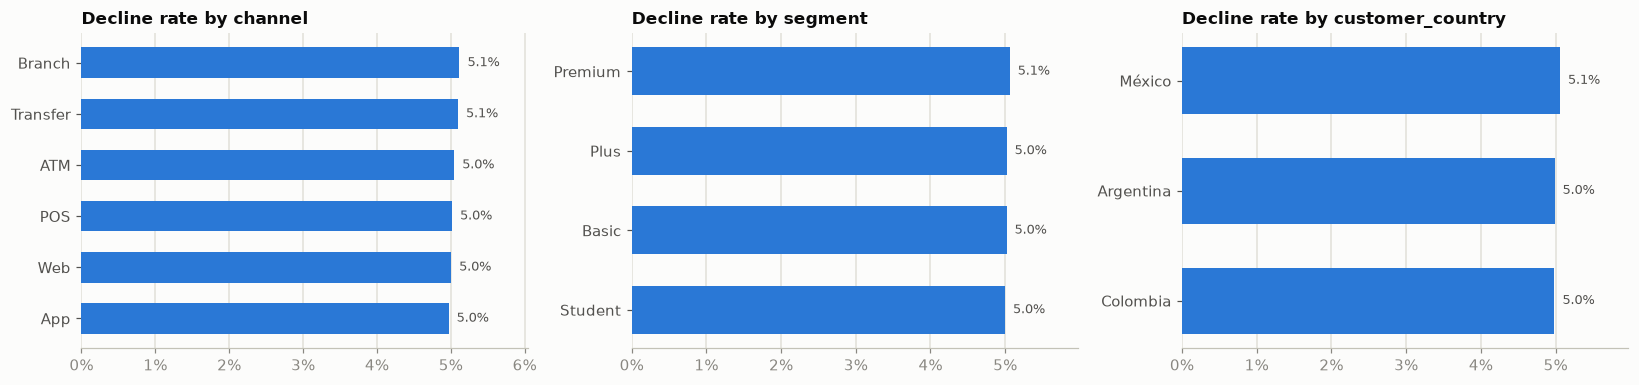

In [56]:
dims = {"card_type": "card_type", "channel": "channel", "customer_country": "customer_country",
        "product_status": "product_status", "segment": "segment"}
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, dim in zip(axes, ["channel", "segment", "customer_country"]):
    s = sql(f"SELECT {dim} AS k, avg((transaction_status='Declined')::INT) AS r FROM card_tx GROUP BY 1 ORDER BY 2 DESC").set_index("k").r
    hbar(ax, s, kind="pct", title=f"Decline rate by {dim}")
plt.tight_layout()

In [57]:
code_checks = sql("""
SELECT response_code,
       count(*) AS declines,
       avg((CAST(transaction_date AS DATE) > expiration_date)::INT) AS card_expired_at_tx_rate,
       avg((product_status <> 'Active')::INT) AS card_not_active_rate
FROM card_tx WHERE transaction_status='Declined' AND response_code IS NOT NULL GROUP BY 1
UNION ALL
SELECT 'Approved (baseline)', count(*),
       avg((CAST(transaction_date AS DATE) > expiration_date)::INT),
       avg((product_status <> 'Active')::INT)
FROM card_tx WHERE transaction_status='Approved' ORDER BY 1""")
code_checks["meaning"] = code_checks.response_code.map(RC)
pct_table(code_checks, ["card_expired_at_tx_rate", "card_not_active_rate"])

,response_code,declines,card_expired_at_tx_rate,card_not_active_rate,meaning
0,05,"18,404",0.310587,0.000000,Do not honor
1,14,"18,534",0.315142,0.000000,Invalid card number
2,51,"18,510",0.320297,0.000000,Insufficient funds
3,54,"18,450",0.314005,0.000000,Expired card
4,Approved (baseline),"1,423,048",0.314306,0.000000,—


In [58]:
util51 = sql("""
SELECT CASE WHEN t.response_code='51' AND t.transaction_status='Declined' THEN 'Declined 51 (insufficient funds)'
            WHEN t.transaction_status='Approved' THEN 'Approved' ELSE 'Other' END AS grp,
       count(*) AS tx, median(k.utilization) AS median_util, avg((k.utilization > 1)::INT) AS over_limit_rate
FROM card_tx t JOIN cards k USING (product_id)
WHERE t.card_type='Credit' GROUP BY 1 ORDER BY 1""")
pct_table(util51, ["over_limit_rate"]).format({"median_util": "{:.1%}"})

,grp,tx,median_util,over_limit_rate
0,Approved,1019373,5.9%,0.012678
1,Declined 51 (insufficient funds),13268,5.9%,0.011816
2,Other,75644,5.9%,0.012631


In [59]:
# Card transactions by the card's *current* status (all non-Active cards are absent: they have no transactions).
inactive_tx = sql("""SELECT k.product_status, count(t.transaction_id) AS tx, count(DISTINCT k.product_id) AS cards,
                            count(DISTINCT t.product_id) AS cards_with_tx
                     FROM cards k LEFT JOIN card_tx t USING (product_id) GROUP BY 1 ORDER BY cards DESC""")
inactive_tx

,product_status,tx,cards,cards_with_tx
0,Active,1547432,118839,118839
1,Closed,0,11297,0
2,Blocked,0,7044,0
3,Suspended,0,2860,0


In [60]:
xb = sql("""SELECT customer_country, avg((transaction_country <> customer_country)::INT) AS cross_border_rate,
                   avg((transaction_status='Declined')::INT) FILTER (WHERE transaction_country <> customer_country) AS decline_rate_cross_border,
                   avg((transaction_status='Declined')::INT) FILTER (WHERE transaction_country = customer_country) AS decline_rate_domestic
            FROM card_tx GROUP BY 1""")
pct_table(xb, ["cross_border_rate", "decline_rate_cross_border", "decline_rate_domestic"])

,customer_country,cross_border_rate,decline_rate_cross_border,decline_rate_domestic
0,Argentina,0.050272,0.046456,0.050045
1,México,0.049912,0.050164,0.050609
2,Colombia,0.049969,0.050043,0.049840


In [61]:
note("Authorizations", "~5% of card transactions are declined, using only 4 response codes (05, 14, 51, 54), each ~25% of declines; "
     "the decline rate is flat (~5%) across channel, country, card type and domestic vs. cross-border.",
     "'Why was my card declined?' is well supported: the agent can look up the transaction and explain the code (with a team-written code→explanation table).")
cc54 = code_checks.set_index("response_code")
note("Authorizations", f"Response codes do not match card state: code 54 'expired card' hits expired cards at the same rate as approvals "
     f"({cc54.loc['54','card_expired_at_tx_rate']:.0%} vs {cc54.loc['Approved (baseline)','card_expired_at_tx_rate']:.0%}), and code 51 'insufficient funds' "
     "shows the same utilization as approved transactions.",
     "Explain the stored code, not an inferred cause; the synthetic policy must say what the customer can do for each code.")
note("Authorizations", "All card transactions belong to cards whose current status is Active: Closed, Blocked and Suspended cards have no transactions at all.",
     "'My card was blocked after this purchase' cannot be reconstructed from data; block events and reasons must be simulated.")
note("Authorizations", "The same response codes also appear on Pending and Reversed transactions, and ~5% of Approved rows have a null code.",
     "Treat response_code as meaningful only when status = Declined.")

### 6.2 Fraud

,card_type,tx,fraud_rate,fraud_tx,avg_score_fraud,avg_score_legit
0,Credit,1108285,0.001002,1111.000000,50.0,15.0
1,Debit,439147,0.000995,437.000000,51.2,15.0


,flag_rate,precision,recall
threshold,,,
30,0.000857,0.797361,0.695724
40,0.000588,1.000000,0.598684
50,0.000499,1.000000,0.507401
60,0.000395,1.000000,0.402138
70,0.000295,1.000000,0.300164
80,0.000202,1.000000,0.205592


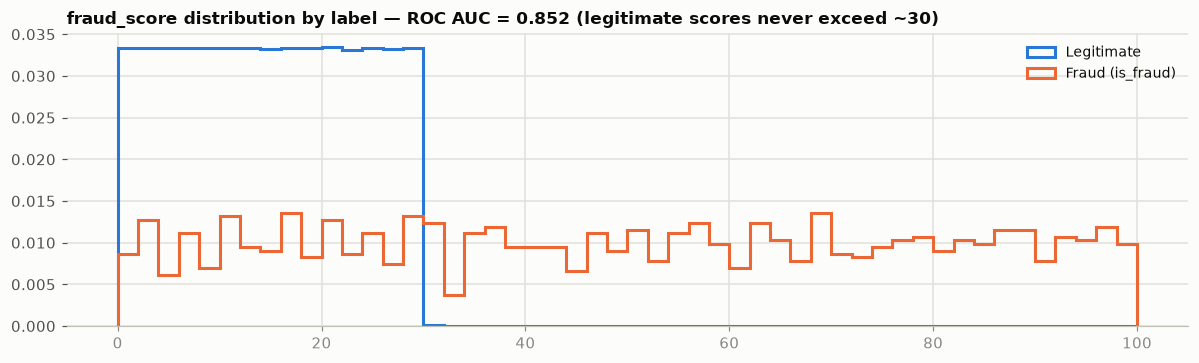

In [62]:
fr = sql("""SELECT card_type, count(*) tx, avg(is_fraud::INT) AS fraud_rate, sum(is_fraud::INT) AS fraud_tx,
                   avg(fraud_score) FILTER (WHERE is_fraud) AS avg_score_fraud,
                   avg(fraud_score) FILTER (WHERE NOT is_fraud) AS avg_score_legit
            FROM card_tx GROUP BY 1""")
display(pct_table(fr, ["fraud_rate"]).format({"avg_score_fraud": "{:.1f}", "avg_score_legit": "{:.1f}"}))

scores = sql("SELECT is_fraud, fraud_score FROM card_tx WHERE fraud_score IS NOT NULL")
r = scores.fraud_score.rank().values  # Mann-Whitney formulation of ROC AUC
pos = scores.is_fraud.values.astype(bool)
auc = (r[pos].sum() - pos.sum() * (pos.sum() + 1) / 2) / (pos.sum() * (~pos).sum())

thr = []
for t in [30, 40, 50, 60, 70, 80]:
    flag = scores.fraud_score >= t
    tp = (flag & pos).sum()
    thr.append({"threshold": t, "flag_rate": flag.mean(), "precision": tp / max(flag.sum(), 1), "recall": tp / pos.sum()})
display(pct_table(pd.DataFrame(thr).set_index("threshold"), ["flag_rate", "precision", "recall"]))

fig, ax = plt.subplots(figsize=(11, 3.4))
bins = np.linspace(0, 100, 51)
ax.hist(scores.fraud_score[~pos], bins=bins, density=True, histtype="step", linewidth=2, color=C["blue"], label="Legitimate")
ax.hist(scores.fraud_score[pos], bins=bins, density=True, histtype="step", linewidth=2, color=C["orange"], label="Fraud (is_fraud)")
ax.set_title(f"fraud_score distribution by label — ROC AUC = {auc:.3f} (legitimate scores never exceed ~30)")
ax.legend()
plt.tight_layout()

In [63]:
fraud_ctx = sql("""
SELECT transaction_status, count(*) FILTER (WHERE is_fraud) AS fraud_tx,
       count(*) FILTER (WHERE is_fraud) / sum(count(*) FILTER (WHERE is_fraud)) OVER () AS share_of_fraud,
       avg(is_fraud::INT) AS fraud_rate
FROM card_tx GROUP BY 1 ORDER BY fraud_tx DESC""")
pct_table(fraud_ctx, ["share_of_fraud", "fraud_rate"])

,transaction_status,fraud_tx,share_of_fraud,fraud_rate
0,Approved,"1,443",0.932171,0.001014
1,Declined,73,0.047158,0.000939
2,Pending,25,0.016150,0.000809
3,Reversed,7,0.004522,0.000443


In [64]:
thr_df = pd.DataFrame(thr).set_index("threshold")
note("Fraud", f"Fraud is rare ({fr.fraud_rate.mean():.2%} of card transactions) and {fraud_ctx.set_index('transaction_status').loc['Approved','share_of_fraud']:.0%} of it was Approved. "
     f"fraud_score ≥ 40 is always fraud (precision {thr_df.loc[40,'precision']:.0%}) but catches only {thr_df.loc[40,'recall']:.0%}; the remaining fraud has legitimate-looking scores (AUC {auc:.2f}).",
     "A high score can justify a proactive 'did you make this purchase?' check; a low score must never be used to reject an unrecognised-charge claim.")

**Section 6 — key takeaways**
- 1.55M card transactions: purchases 70%, withdrawals 15%, payments 15%. By channel: POS 35%, ATM 30%, App 15%, Web 15%.
- Outcomes: 92% Approved, 5% Declined, 2% Pending, 1% Reversed. The **4 decline codes (05, 14, 51, 54) are equally frequent**, and the decline rate is ~5% everywhere.
- Codes carry no causal link to card state, but they are exactly what is needed to *explain* a decline. **Declines are the best-grounded card-support intent in the dataset.**
- Closed, Blocked and Suspended cards have **no transactions**. Fraud is 0.1% and 93% of it was Approved. fraud_score ≥ 40 is always fraud but catches only 60% of it.

## 7. Card-support demand signals

### 7.1 Complaints on cards

,product_group,n,share
0,Other product,"29,084",0.433475
1,No product linked,"22,525",0.335718
2,Credit card,"11,064",0.164901
3,Debit card,"4,422",0.065907


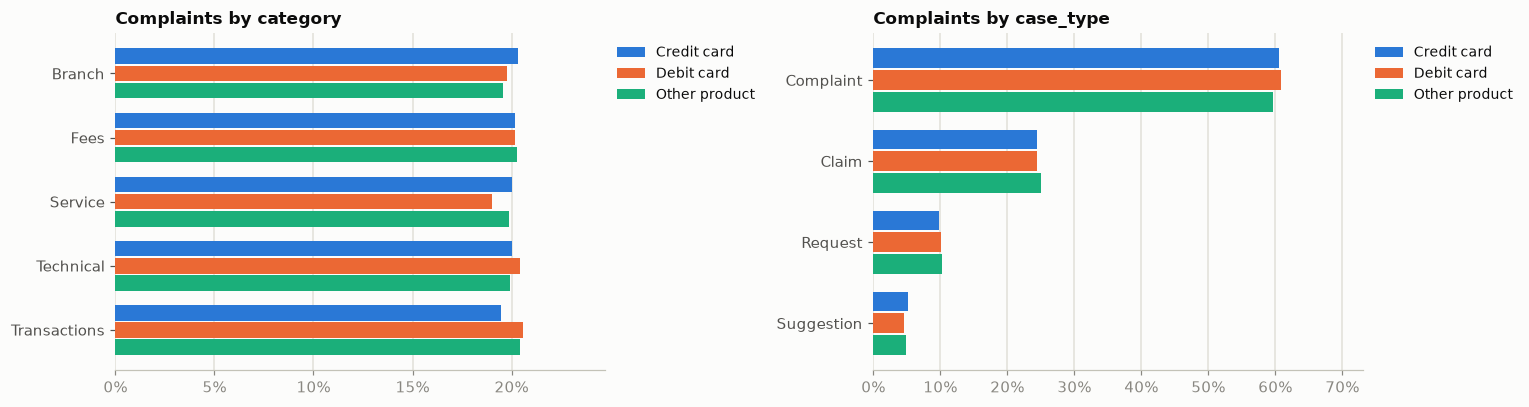

In [65]:
con.execute("""
CREATE OR REPLACE TABLE cmp AS
SELECT c.*, CASE WHEN p.product_id IS NULL THEN 'No product linked'
                 WHEN p.product_type = 'Tarjeta Crédito' THEN 'Credit card'
                 WHEN p.product_type = 'Tarjeta Débito' THEN 'Debit card'
                 ELSE 'Other product' END AS product_group
FROM complaints c LEFT JOIN products p ON c.affected_product_id = p.product_id""")
cmp_share = sql("SELECT product_group, count(*) n, count(*)/sum(count(*)) OVER () AS share FROM cmp GROUP BY 1 ORDER BY n DESC")
display(pct_table(cmp_share, ["share"]))

groups = ["Credit card", "Debit card", "Other product"]
gcol = {"Credit card": C["blue"], "Debit card": C["orange"], "Other product": C["aqua"]}
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
for ax, dim in zip(axes, ["category", "case_type"]):
    t = sql(f"SELECT coalesce({dim},'(null)') k, product_group, count(*) n FROM cmp WHERE product_group IN ('Credit card','Debit card','Other product') GROUP BY ALL").pivot_table(
        index="k", columns="product_group", values="n")[groups]
    grouped_hbar(ax, (t / t.sum()).sort_values("Credit card", ascending=False), gcol, kind="pct", title=f"Complaints by {dim}", labels=False)
plt.tight_layout()

In [66]:
sub = sql("""SELECT category, coalesce(subcategory,'(null)') AS subcategory, count(*) n FROM cmp
             WHERE product_group IN ('Credit card','Debit card') GROUP BY ALL ORDER BY category, n DESC""")
sub

,category,subcategory,n
0,Branch,Atención en sucursal,2792
1,Branch,(null),330
2,Fees,Cobro indebido,2833
3,Fees,(null),292
4,Service,Calidad de servicio,2763
5,Service,(null),293
6,Technical,Problema con app,2793
7,Technical,(null),325
8,Transactions,Cargo no reconocido,2772
9,Transactions,(null),293


In [67]:
ops = sql("""
SELECT product_group, count(*) AS complaints,
       avg(sla_breached::INT) AS sla_breach_rate,
       median(resolution_days) AS median_resolution_days,
       avg((status IN ('Resolved','Closed'))::INT) AS resolved_rate,
       avg((status = 'Escalated')::INT) AS escalated_rate,
       avg((priority IN ('High','Critical'))::INT) AS high_priority_rate,
       avg((coalesce(compensation_granted, 0) > 0)::INT) AS compensation_rate,
       avg(resolution_satisfaction) AS avg_resolution_satisfaction,
       avg(is_repeat_complainer::INT) AS repeat_complainer_rate
FROM cmp GROUP BY 1 ORDER BY complaints DESC""")
pct_table(ops, ["sla_breach_rate", "resolved_rate", "escalated_rate", "high_priority_rate", "compensation_rate", "repeat_complainer_rate"]).format(
    {"median_resolution_days": "{:.0f}", "avg_resolution_satisfaction": "{:.2f}"})

,product_group,complaints,sla_breach_rate,median_resolution_days,resolved_rate,escalated_rate,high_priority_rate,compensation_rate,avg_resolution_satisfaction,repeat_complainer_rate
0,Other product,29084,0.196809,16,0.239651,0.049202,0.198700,0.069179,2.98,0.151802
1,No product linked,22525,0.202131,15,0.240488,0.049634,0.199290,0.069967,3.04,0.150633
2,Credit card,11064,0.208424,16,0.241052,0.049078,0.190799,0.069053,3.07,0.147054
3,Debit card,4422,0.206242,16,0.241294,0.051787,0.195839,0.065355,3.05,0.147218


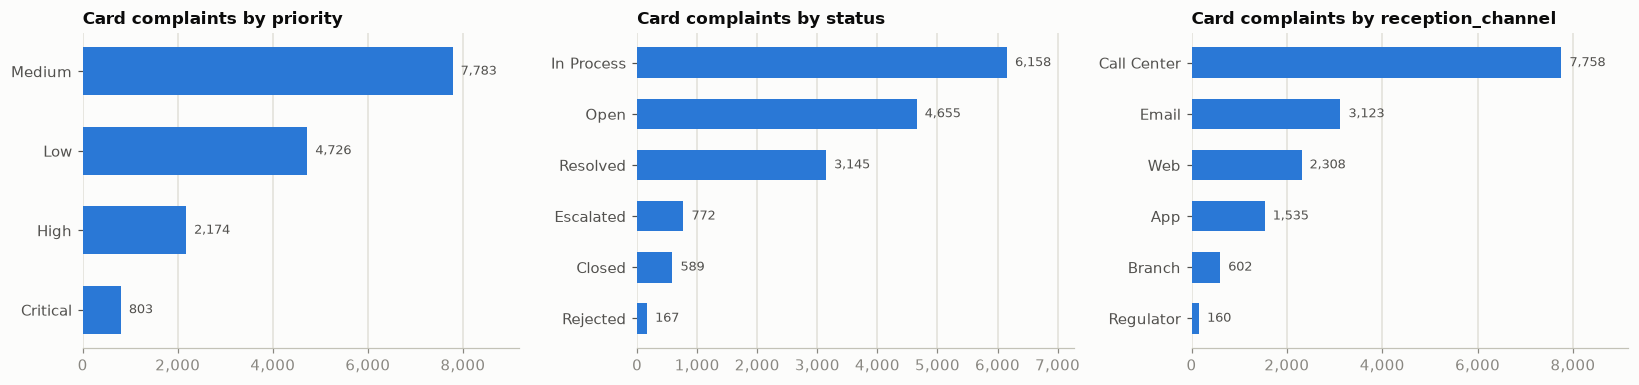

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, dim in zip(axes, ["priority", "status", "reception_channel"]):
    t = sql(f"SELECT coalesce({dim},'(null)') k, count(*) n FROM cmp WHERE product_group IN ('Credit card','Debit card') GROUP BY 1 ORDER BY n DESC").set_index("k").n
    hbar(ax, t, color=C["blue"], title=f"Card complaints by {dim}")
plt.tight_layout()

In [69]:
sla_by = sql("""SELECT priority, count(*) n, avg(sla_breached::INT) AS sla_breach_rate, median(resolution_days) AS median_resolution_days
               FROM cmp WHERE product_group IN ('Credit card','Debit card') GROUP BY 1 ORDER BY 1""")
pct_table(sla_by, ["sla_breach_rate"])

,priority,n,sla_breach_rate,median_resolution_days
0,Critical,803,0.189290,16
1,High,"2,174",0.216191,17
2,Low,"4,726",0.204401,17
3,Medium,"7,783",0.209431,16


In [70]:
n_card_cmp = ops.set_index("product_group").loc[["Credit card", "Debit card"], "complaints"].sum()
no_pid = cmp_share.set_index("product_group").loc["No product linked", "share"]
note("Complaints", f"{n_card_cmp:,} complaints ({n_card_cmp / ops.complaints.sum():.0%}) are linked to a card; {no_pid:.0%} of all complaints have no linked product. "
     "Category has 5 values with exactly 1 subcategory each (e.g. Transactions → 'Cargo no reconocido', Fees → 'Cobro indebido'), ~10% null.",
     "Card disputes ('unrecognised charge', 'wrong fee') map directly onto complaint categories and are the natural hand-off to the dispute-intake workflow.")
card_ops = ops.set_index("product_group").loc["Credit card"]
note("Complaints", f"SLA breach (~{card_ops.sla_breach_rate:.0%}), median resolution (~{card_ops.median_resolution_days:.0f} days), resolved share (~{card_ops.resolved_rate:.0%}) "
     f"and compensation (~{card_ops.compensation_rate:.0%}) are the same for card and non-card complaints and across priorities.",
     "The data does not show that priority changes outcomes; SLA targets per priority must be defined in the synthetic policy.")

### 7.2 Call-center interactions: what the text and labels can support

In [71]:
lim = sql("""
SELECT (SELECT avg((contact_reason = reason_category)::INT) FROM interactions) AS contact_reason_equals_category_rate,
       (SELECT count(DISTINCT contact_reason) FROM interactions) AS distinct_contact_reasons,
       (SELECT count(DISTINCT customer_text) FROM transcripts) AS distinct_customer_texts,
       (SELECT count(DISTINCT detected_intents) FROM transcripts) AS distinct_detected_intents,
       (SELECT avg((customer_text ILIKE '%tarjeta%')::INT) FROM transcripts) AS transcripts_mentioning_card_rate,
       (SELECT avg(has_transcript::INT) FROM interactions) AS has_transcript_rate""")
display(pct_table(lim, ["contact_reason_equals_category_rate", "transcripts_mentioning_card_rate", "has_transcript_rate"]))
sql("""SELECT left(customer_text, 110) AS customer_text_template, detected_intents, count(*) n
       FROM transcripts GROUP BY ALL ORDER BY n DESC LIMIT 6""")

,contact_reason_equals_category_rate,distinct_contact_reasons,distinct_customer_texts,distinct_detected_intents,transcripts_mentioning_card_rate,has_transcript_rate
0,1.000000,6,42,1,0.501456,0.249631


,customer_text_template,detected_intents,n
0,"Buenas tardes, necesito consultar el saldo de mi tarjeta de crédito.",consulta_general,49004
1,"Hola, buenos días. Quisiera saber cuál es mi saldo actual en mi cuenta de ahorros.",consulta_general,48727
2,"Hola, buenos días. Quisiera saber cuál es mi saldo actual en mi cuenta de ahorros. Muy bien, ¿hay algo más que",consulta_general,8249
3,"Hola, buenos días. Quisiera saber cuál es mi saldo actual en mi cuenta de ahorros. ¿Y eso cuánto tiempo tarda?",consulta_general,8181
4,"Hola, buenos días. Quisiera saber cuál es mi saldo actual en mi cuenta de ahorros. Perfecto, eso es lo que nec",consulta_general,8107
5,"Buenas tardes, necesito consultar el saldo de mi tarjeta de crédito. Perfecto, eso es lo que necesitaba.",consulta_general,4167


In [72]:
note("Interactions", f"contact_reason always equals reason_category (6 values). Transcripts contain only {lim.distinct_customer_texts[0]} distinct customer texts, "
     "all opening with one of 2 sentences (savings balance / credit-card balance), and detected_intents is always 'consulta_general'.",
     "There are no card-specific intent labels or realistic utterances. The card-support intent set and the Spanish + Portuguese test set must be team-generated and labelled as such.")

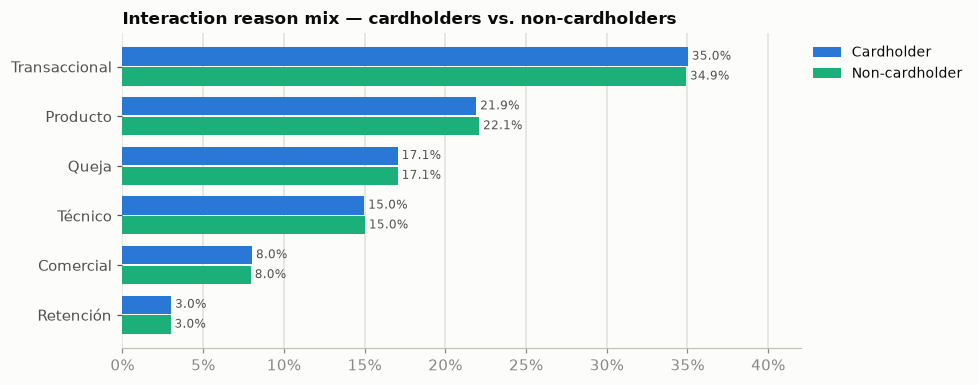

In [73]:
reason = sql("""
WITH h AS (SELECT DISTINCT customer_id FROM cards)
SELECT reason_category, (i.customer_id IN (SELECT customer_id FROM h)) AS is_cardholder, count(*) n
FROM interactions i GROUP BY ALL""").pivot_table(index="reason_category", columns="is_cardholder", values="n")
reason.columns = ["Non-cardholder", "Cardholder"]
reason = reason[["Cardholder", "Non-cardholder"]]
fig, ax = plt.subplots(figsize=(9, 3.6))
grouped_hbar(ax, (reason / reason.sum()).sort_values("Cardholder", ascending=False), {"Cardholder": C["blue"], "Non-cardholder": C["aqua"]},
             kind="pct", title="Interaction reason mix — cardholders vs. non-cardholders")
plt.tight_layout()

### 7.3 Do card events trigger contacts?
For each card transaction (excluding the last 30 days, so every event has a full follow-up window) we check whether
the same customer contacted the bank in the next 7 days, or filed a complaint in the next 30 days.
A 10% sample of approved transactions serves as the baseline.

In [74]:
con.execute(f"""
CREATE OR REPLACE TABLE ev AS
SELECT transaction_id, customer_id, transaction_date, transaction_status, is_fraud, card_type
FROM card_tx
WHERE transaction_date < TIMESTAMP '{AS_OF}' - INTERVAL 30 DAY
  AND (transaction_status <> 'Approved' OR is_fraud OR hash(transaction_id) % 10 = 0)""")
contact = sql("""
WITH e AS (
  SELECT ev.*,
         CASE WHEN is_fraud THEN 'Fraud (any status)' ELSE transaction_status END AS event_group
  FROM ev),
ic AS (
  SELECT e.transaction_id, max(1) AS contact_7d, max((i.reason_category='Queja')::INT) AS complaint_call_7d
  FROM e JOIN interactions i ON i.customer_id = e.customer_id
   AND i.interaction_date > e.transaction_date AND i.interaction_date <= e.transaction_date + INTERVAL 7 DAY
  GROUP BY 1),
cc AS (
  SELECT e.transaction_id, 1 AS complaint_30d
  FROM e JOIN complaints c ON c.customer_id = e.customer_id
   AND c.creation_date > e.transaction_date AND c.creation_date <= e.transaction_date + INTERVAL 30 DAY
  GROUP BY 1)
SELECT event_group, count(*) AS events,
       avg(coalesce(contact_7d,0)) AS contact_7d_rate,
       avg(coalesce(complaint_call_7d,0)) AS complaint_call_7d_rate,
       avg(coalesce(complaint_30d,0)) AS complaint_30d_rate
FROM e LEFT JOIN ic USING (transaction_id) LEFT JOIN cc USING (transaction_id)
GROUP BY 1 ORDER BY events DESC""")
base = contact.set_index("event_group").loc["Approved"]
for c_ in ["contact_7d_rate", "complaint_30d_rate"]:
    contact[c_.replace("_rate", "_lift")] = contact[c_] / base[c_]
pct_table(contact, ["contact_7d_rate", "complaint_call_7d_rate", "complaint_30d_rate"]).format(
    {"contact_7d_lift": "{:.2f}x", "complaint_30d_lift": "{:.2f}x"})

,event_group,events,contact_7d_rate,complaint_call_7d_rate,complaint_30d_rate,contact_7d_lift,complaint_30d_lift
0,Approved,138240,0.028885,0.005049,0.012030,1.00x,1.00x
1,Declined,75359,0.027840,0.004923,0.012912,0.96x,1.07x
2,Pending,29954,0.027709,0.005141,0.012252,0.96x,1.02x
3,Reversed,15308,0.026718,0.005226,0.014110,0.92x,1.17x
4,Fraud (any status),1513,0.029742,0.007270,0.011236,1.03x,0.93x


In [75]:
cust_level = sql("""
WITH k AS (
  SELECT customer_id,
         max(CASE WHEN card_type='Credit' THEN coalesce(days_past_due,0) END) AS max_dpd,
         bool_or(product_status IN ('Blocked','Suspended')) AS has_blocked
  FROM cards GROUP BY 1),
i AS (SELECT customer_id, count(*) AS interactions FROM interactions GROUP BY 1),
c AS (SELECT customer_id, count(*) AS complaints FROM complaints GROUP BY 1)
SELECT CASE WHEN has_blocked THEN 'Has Blocked/Suspended card'
            WHEN max_dpd >= 90 THEN 'Credit card 90+ DPD'
            WHEN max_dpd > 0 THEN 'Credit card 1-89 DPD'
            ELSE 'Cards in good standing' END AS cardholder_group,
       count(*) AS customers,
       avg(coalesce(i.interactions,0)) AS interactions_per_customer,
       avg((coalesce(c.complaints,0) > 0)::INT) AS complained_rate
FROM k LEFT JOIN i USING (customer_id) LEFT JOIN c USING (customer_id)
GROUP BY 1 ORDER BY customers DESC""")
pct_table(cust_level, ["complained_rate"]).format({"interactions_per_customer": "{:.2f}"})

,cardholder_group,customers,interactions_per_customer,complained_rate
0,Cards in good standing,69659,4.58,0.366600
1,Has Blocked/Suspended card,9600,4.59,0.363333
2,Credit card 90+ DPD,6049,4.62,0.362705
3,Credit card 1-89 DPD,5776,4.56,0.364958


In [76]:
decl = contact.set_index("event_group")
note("Demand", f"Customers do not contact the bank more after a decline ({decl.loc['Declined','contact_7d_lift']:.2f}x the approved baseline within 7 days) "
     "or after fraud, and delinquent or blocked cardholders do not generate more interactions or complaints.",
     "The synthetic data has no causal event→contact signal. Size card-support demand from card-state prevalence (declines, expired and blocked cards, DPD), not from observed contact lift.")

### 7.4 Digital behaviour around cards

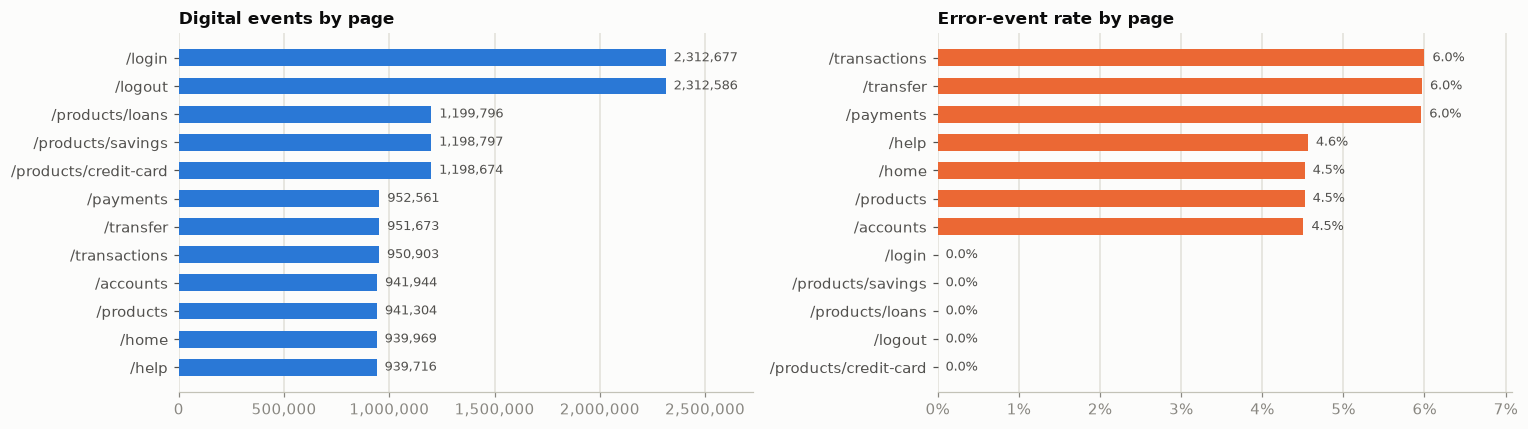

In [77]:
dig = sql("""
SELECT coalesce(page_url,'(null)') AS page_url, count(*) AS events,
       avg((event_type='Error')::INT) AS error_rate
FROM digital_events GROUP BY 1 ORDER BY events DESC""")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
hbar(axes[0], dig.set_index("page_url").events.head(12), title="Digital events by page")
hbar(axes[1], dig.set_index("page_url").error_rate.head(12).sort_values(ascending=False), kind="pct", color=C["orange"], title="Error-event rate by page")
plt.tight_layout()

,product_type,events
0,Cuenta Ahorro,431903
1,Tarjeta Crédito,361274
2,Cuenta Corriente,360007
3,Tarjeta Débito,144048
4,Préstamo Personal,71729
5,Préstamo Hipotecario,43065
6,Inversión,21039
7,Seguro,7273


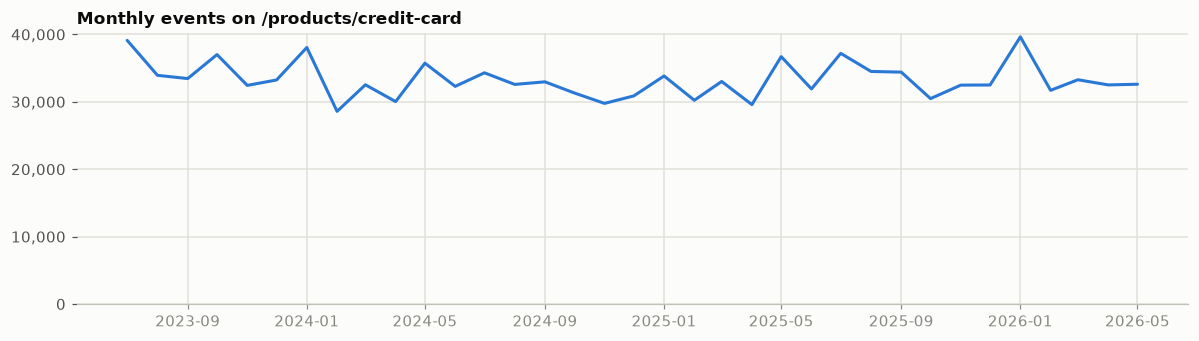

In [78]:
cc_page = sql("""
SELECT date_trunc('month', event_date) m, count(*) AS credit_card_page_events,
       count(DISTINCT customer_id) AS customers
FROM digital_events WHERE page_url='/products/credit-card' GROUP BY 1 ORDER BY 1""").set_index("m").iloc[1:-1]
card_prod_events = sql("""
SELECT p.product_type, count(*) AS events FROM digital_events d JOIN products p USING (product_id)
GROUP BY 1 ORDER BY 2 DESC""")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(cc_page.index, cc_page.credit_card_page_events, color=C["blue"])
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Monthly events on /products/credit-card")
plt.tight_layout()
card_prod_events

In [79]:
dg = dig.set_index("page_url")
note("Digital", f"digital_events has {actual['digital_events']:,} rows on 12 generic pages. Errors occur only on transactional pages "
     f"(/payments, /transfer, /transactions ≈ {dg.loc['/payments','error_rate']:.0%}) and navigation pages (≈ {dg.loc['/home','error_rate']:.1%}); "
     "product pages, login and logout have 0 errors, and there is no card-management page (block, PIN, limits, travel notice).",
     "Self-service deflection for card tasks cannot be measured from the data; digital error events only support generic 'app error' troubleshooting.")

**Section 7 — key takeaways**
- **23% of complaints concern a card** (credit 16.5%, debit 6.6%). Categories are 5 flat buckets, each with a single subcategory. Outcomes are uniform: ~21% SLA breach, median 16 days to resolve, ~24% resolved.
- The interaction text and labels are templated (42 customer texts, 1 intent value), and `contact_reason` has only 6 coarse values. **There are no card-support utterances to train or evaluate on.**
- **No event→contact signal:** declines, fraud, delinquency and blocks do not raise contact or complaint rates (lift ≈ 1.0).
- Digital logs have no card-management actions, and errors appear only on transactional and navigation pages.

## 8. Implications for the Card Support workflow

### 8.1 Candidate intents vs. data support

| Intent (Spanish example) | Data support | Grounding fields | Needs synthetic policy / fixture |
|---|---|---|---|
| Explain a declined transaction (*"¿por qué rechazaron mi compra?"*) | ✅ Strong: ~77K declines with a code | `card_tx`: date, amount, currency, merchant_category, channel, status, response_code | Code → customer-facing explanation and next steps |
| Balance, limit, available credit (*"¿cuánto cupo tengo?"*) | ✅ Strong | `cards`: current_balance, credit_limit, currency | Display rule for USD-denominated Mexican cards |
| Expiration and replacement (*"mi tarjeta venció"*) | ✅ Strong: 48% of Active cards expired | `cards`: expiration_date, product_status | Reissue policy, delivery time, fee |
| Recent card movements | ✅ | `card_tx` | UTC → local date rule |
| Card status / blocked card (*"mi tarjeta está bloqueada"*) | ⚠️ Partial: ~7K Blocked, ~2.9K Suspended, no reason, no history | `cards.product_status`, `customers.customer_status` | Block reasons, unblock rules, step-up authentication |
| Past due / collections (*"¿cuánto debo y desde cuándo?"*) | ⚠️ Partial: DPD bucket only | `days_past_due` (bucket), balance | Late fees, payment plans, hand-off to collections |
| Wrong fee (*"cobro indebido"*) | ⚠️ Complaints only, no fee transactions | complaints Fees / *Cobro indebido* | Fee schedule |
| Unrecognised charge / fraud → dispute | ✅ as a hand-off | `card_tx` (is_fraud, fraud_score), complaints Transactions / *Cargo no reconocido* | Block-card action; dispute-intake workflow |
| Payment due date / minimum payment | ❌ Fields absent | — | Billing cycle, due date, minimum-payment formula |
| Lost or stolen card, block and reissue | ❌ No events | card selection only | Simulated block/reissue action with confirmation |
| Limit increase / new card eligibility | ❌ Terms unrelated to risk attributes | credit_score, income, segment (context only) | Labelled synthetic eligibility service |
| Activation, PIN, travel notice | ❌ | — | Fully simulated |

**Cross-cutting requirements:**
- All text is Spanish, so the Portuguese test cases must be team-generated.
- Authentication must come from a trusted test session; `customer_id` alone is not sufficient.
- Only the masked minimal context (§8.2) should be sent to an LLM.

### 8.2 Prototype: minimal card context for the agent
A tool the agent would call after the customer has been authenticated through a trusted test session.
It returns the **minimum** masked data needed to answer card questions and never exposes full card numbers or personal identifiers.

In [80]:
RESPONSE_CODE_EXPLANATION = {  # team-written, synthetic policy text (assumption: ISO 8583 semantics)
    "05": "The issuer declined the transaction (do not honor). Usually a security or risk rule.",
    "14": "The card number was not recognised by the network.",
    "51": "Insufficient available funds or credit at the time of the transaction.",
    "54": "The card was reported as expired at the time of the transaction.",
}


def card_context(customer_id: str, recent_declines: int = 3) -> dict:
    cust = con.execute("""SELECT customer_id, segment, country, customer_status FROM customers WHERE customer_id = ?""",
                       [customer_id]).df()
    if cust.empty:
        return {"error": "customer_not_found"}
    cards_df = con.execute(f"""
        SELECT product_id, card_masked, card_type, currency, product_status, expiry_status, expiration_date,
               round(current_balance, 2) AS balance, round(credit_limit, 2) AS credit_limit,
               round(credit_limit - current_balance, 2) AS available_credit, dpd_bucket, has_linked_app
        FROM cards WHERE customer_id = ? ORDER BY card_type, product_status""", [customer_id]).df()
    declines = con.execute(f"""
        SELECT t.product_id, CAST(t.transaction_date AS DATE) AS date, t.amount, t.currency, t.merchant_category,
               t.channel, t.response_code
        FROM card_tx t WHERE t.customer_id = ? AND t.transaction_status = 'Declined'
        ORDER BY t.transaction_date DESC LIMIT {int(recent_declines)}""", [customer_id]).df()
    declines["explanation"] = declines.response_code.map(RESPONSE_CODE_EXPLANATION)
    masked = dict(zip(cards_df.product_id, cards_df.card_masked))
    declines["card"] = declines.pop("product_id").map(masked)
    cards_df["expiration_date"] = cards_df.expiration_date.dt.date
    declines["date"] = pd.to_datetime(declines.date).dt.date
    clean = lambda df: df.astype(object).where(df.notna(), None).to_dict("records")
    return {
        "customer": cust.iloc[0].to_dict(),
        "cards": clean(cards_df.drop(columns="product_id")),
        "recent_declines": clean(declines),
        "flags": {
            "active_but_expired": int(((cards_df.product_status == "Active") & (cards_df.expiry_status == "Expired")).sum()),
            "past_due_cards": int(cards_df.dpd_bucket.fillna("0 (current)").ne("0 (current)").sum()),
            "customer_not_active": cust.customer_status[0] != "Active",
        },
    }


example_id = sql("""SELECT customer_id FROM cards WHERE card_type='Credit' AND days_past_due > 0 AND expiry_status='Expired'
                    AND customer_id IN (SELECT customer_id FROM card_tx WHERE transaction_status='Declined')
                    ORDER BY customer_id LIMIT 1""").customer_id[0]
import json  # noqa: E402

print(json.dumps(card_context(example_id), indent=2, default=str, ensure_ascii=False))

{
  "customer": {
    "customer_id": "CLI-00D4B1GTAW7M",
    "segment": "Basic",
    "country": "Colombia",
    "customer_status": "Active"
  },
  "cards": [
    {
      "card_masked": "**** 6749",
      "card_type": "Credit",
      "currency": "COP",
      "product_status": "Active",
      "expiry_status": "Expired",
      "expiration_date": "2025-07-24",
      "balance": 4353443.83,
      "credit_limit": 122219512.26,
      "available_credit": 117866068.43,
      "dpd_bucket": "30",
      "has_linked_app": false
    },
    {
      "card_masked": "**** 5596",
      "card_type": "Credit",
      "currency": "COP",
      "product_status": "Closed",
      "expiry_status": "Expired",
      "expiration_date": "2026-04-12",
      "balance": 4657964.23,
      "credit_limit": 90558637.86,
      "available_credit": 85900673.63,
      "dpd_bucket": "0 (current)",
      "has_linked_app": true
    },
    {
      "card_masked": "**** 6427",
      "card_type": "Debit",
      "currency": "COP",
     

## 9. Findings register

In [81]:
findings = pd.DataFrame(FINDINGS)
with pd.option_context("display.max_colwidth", None):
    display(findings.style.set_properties(**{"text-align": "left", "white-space": "pre-wrap"}).hide(axis="index"))

area,finding,impact_on_card_support
Data quality,"Row counts differ from the data dictionary: transactions 4,425,008 (89% of documented), call_center_interactions 686,296 (86% of documented), call_transcripts 171,321 (86% of documented), complaints 67,095 (84% of documented), digital_events 15,620,994 (156% of documented).","Quote real counts, not dictionary counts, in the submission and in any sizing."
Data quality,"No duplicate keys or content duplicates found in customers, products or transactions, despite the documented ~2% duplicate rate.","Keep dedup checks in the pipeline as data contracts, but this delivery needs no dedup step."
Data quality,"99% of product IDs in interactions.mentioned_products do not exist in products (only 1,223 resolve to a card).",Interactions cannot be linked to a specific card; link at customer level (customer_id + time window) instead.
Data quality,customers.estimated_monthly_income is null for 20% and detected_accent for 30% of customers (well above the documented ~5%).,Income-based eligibility and accent-based routing must handle 'unknown' explicitly.
Data quality,"Every Closed, Blocked and Suspended card has a null last_transaction_date, and (see §6) none of them has a single transaction; 10% of Active cards also lack one.",There is no history explaining *why* a card was blocked or closed; the synthetic policy must supply block reasons.
Data quality,"8,692 cards (6.2%) have last_updated in the future (up to 2027).",Treat last_updated as unreliable; do not use it to explain 'when did my card change'.
Data quality,"288,617 card transactions (19%) are dated before the card was opened.",Transaction history and card lifecycle are generated independently; never infer a card's age or activation from its transactions.
Data quality,"process_date = transaction_date − 1 day for ~25% of rows (00:00–05:59 timestamps): a UTC vs. local-time offset, not late data.",Show customers the local transaction date; convert timestamps consistently before comparing with statements.
Data quality,"462,419 card transactions (30%) are dated after the card's expiration date, most of them Approved.",The agent cannot assume an expired card stops transacting; see the response-code analysis in §6.
Data quality,"There is no MXN anywhere in products or transactions: every Mexican card is denominated in USD, while Mexican incomes are in MXN.",Present Mexican balances in USD as stored; convert with daily_exchange_rates when comparing with income.
